#  Acoustic Anomaly Detection for Industrial Machines

**DCASE 2024 Task 2 - First-Shot Unsupervised Anomaly Detection**

## Problem
Detect abnormal machine sounds using **only normal training samples** — no anomaly examples available during training.

## Approach
- **Multi-Task CNN Autoencoder** (Reconstruction + Machine Type Classification)
- **7 machine types**: ToyCar, ToyTrain, bearing, fan, gearbox, slider, valve
- Source domain training → Target domain testing (domain shift robustness)

## Key Features
- Per-machine models trained independently
- Two scoring methods: Reconstruction MSE & k-NN latent distance
- Explainable predictions (top anomalous frequency bands)
- REST API with FastAPI + ngrok for real-time deployment

## Results
Multi-Task model with k-NN scoring achieves best anomaly detection performance with real-time inference capabilities.

# **Phase 1 — Data Ingestion, Validation & Dataset Card**

**SUMMARY:**

  **Step 1:** Installed all required packages including librosa, soundfile, PyTorch (with CUDA), FastAPI, scikit-learn, and visualization libraries

  **Step 2:** Imported libraries, set random seeds for reproducibility, configured compute device (GPU/CPU), and defined master CONFIG dictionary with audio, spectrogram, training, and multi-task parameters

  **Step 3:** Mounted Google Drive and created structured project directories (Features, Models, Outputs, Logs) for organized file management

  **Step 4:** Implemented dataset scanner to parse DCASE filename conventions, extracting machine type, domain, split, and label from 8,400 audio files into a DataFrame

  **Step 5:** Generated summary tables and visualizations (bar charts, pie chart) showing distribution across 7 machine types, splits, and domains

  **Step 6:** Validated all audio files for correct sample rate (16kHz), expected duration (10 seconds), clipping, and file integrity

**Step 7:** Created a JSON dataset card documenting dataset statistics, splits, audio specifications, usage notes, and proposed multi-task learning enhancement



In [ ]:
#step 1: Package Installation


!pip install -q librosa soundfile
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q fastapi uvicorn pyngrok nest-asyncio
!pip install -q scikit-learn matplotlib seaborn pandas numpy scipy tqdm rich
print("✅ All packages installed.")


✅ All packages installed.


In [ ]:
# Step 2: Imports & Global Configuration
import os, sys, json, hashlib, warnings, shutil, time
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import soundfile as sf
import scipy.stats as stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device      : {device}")
print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ CUDA avail  : {torch.cuda.is_available()}")

# ── Master Configuration ────────────────────────────────────────────────────
CONFIG = {
    # Audio
    'sample_rate'              : 16000,
    'clip_duration'            : 10,      # seconds — pad/trim to this length
    # Mel Spectrogram
    'n_mels'                   : 128,
    'n_fft'                    : 1024,
    'hop_length'               : 512,
    'win_length'               : 1024,
    'fmax'                     : 8000,
    'power'                    : 2.0,
    # Training
    'batch_size'               : 32,
    'learning_rate'            : 3e-4,
    'epochs'                   : 50,
    'weight_decay'             : 1e-5,
    'patience'                 : 15,      # early stopping patience
    # Model
    'latent_dim'               : 128,
    'dropout'                  : 0.3,
    # Multi-task weights
    'recon_weight'             : 10.0,
    'class_weight'             : 0.5,
    # Evaluation
    'anomaly_threshold_pct'    : 90,      # percentile on val normal scores
    'pAUC_max_fpr'             : 0.1,
}

print("\n✅ CONFIG loaded — adjust values above as needed.")


✅ Device      : cuda
✅ PyTorch     : 2.10.0+cu128
✅ CUDA avail  : True

✅ CONFIG loaded — adjust values above as needed.


In [ ]:
# Step 3: Google Drive Mounting & Directory Setup
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH    = Path('/content/drive/MyDrive/ML_Project')
DATASET_PATH = BASE_PATH / 'Datasets/DCASE_dataset'
FEATURE_PATH = BASE_PATH / 'Features'
MODEL_PATH   = BASE_PATH / 'Models'
OUTPUT_PATH  = BASE_PATH / 'Outputs'
LOG_PATH     = BASE_PATH / 'Logs'

for p in [FEATURE_PATH, MODEL_PATH, OUTPUT_PATH, LOG_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print(f"📁 Dataset  : {DATASET_PATH}")
print(f"📁 Features : {FEATURE_PATH}")
print(f"📁 Models   : {MODEL_PATH}")
print(f"📁 Outputs  : {OUTPUT_PATH}")
print(f"\nDataset folder contents:")
for item in sorted(DATASET_PATH.iterdir()):
    print(f"  {'📂' if item.is_dir() else '📄'} {item.name}")


Mounted at /content/drive
📁 Dataset  : /content/drive/MyDrive/ML_Project/Datasets/DCASE_dataset
📁 Features : /content/drive/MyDrive/ML_Project/Features
📁 Models   : /content/drive/MyDrive/ML_Project/Models
📁 Outputs  : /content/drive/MyDrive/ML_Project/Outputs

Dataset folder contents:
  📂 ToyCar
  📂 ToyTrain
  📂 bearing
  📂 fan
  📂 gearbox
  📂 slider
  📂 valve


In [ ]:
# Step 4: Dataset Scanner Implementation (Filename Parsing)

def scan_dataset(base_path: Path) -> pd.DataFrame:
    """
    Scans the dataset and correctly parses domain, split, and label
    from the DCASE filename format:
        section_00_source_test_anomaly_0001_...wav
    """
    records = []
    if not base_path.exists():
        print(f"❌ Path not found: {base_path}")
        return pd.DataFrame()

    for wav_file in sorted(base_path.rglob('*.wav')):
        parts = wav_file.parts

        # Machine type = first subfolder under dataset root
        try:
            rel_idx      = parts.index(base_path.name)
            machine_type = parts[rel_idx + 1] if rel_idx + 1 < len(parts) else 'unknown'
        except ValueError:
            machine_type = 'unknown'

        # ── Parse from filename ───────────────────────────────────────────
        # Format: section_00_source_test_anomaly_0001_...
        stem       = wav_file.stem          # drop .wav
        tok        = stem.split('_')        # tokenise by underscore

        # section index is tok[1] e.g. '00'
        section = tok[1] if len(tok) > 1 else 'unknown'

        # domain: 'source' or 'target' — tok[2]
        domain = tok[2] if len(tok) > 2 and tok[2] in ('source','target') else 'unknown'

        # split: 'train' or 'test' — tok[3]
        split  = tok[3] if len(tok) > 3 and tok[3] in ('train','test') else 'unknown'

        # label: 'normal' or 'anomaly' — tok[4]
        label  = tok[4] if len(tok) > 4 and tok[4] in ('normal','anomaly') else 'unknown'

        records.append({
            'path'         : str(wav_file),
            'machine_type' : machine_type,
            'section'      : section,
            'domain'       : domain,
            'split'        : split,
            'label'        : label,
            'filename'     : wav_file.name,
        })

    df = pd.DataFrame(records)
    print(f"✅ Scanned {len(df):,} audio files")
    print(f"   Machine types : {sorted(df['machine_type'].unique().tolist())}")
    print(f"   Domains       : {sorted(df['domain'].unique().tolist())}")
    print(f"   Splits        : {sorted(df['split'].unique().tolist())}")
    print(f"   Labels        : {sorted(df['label'].unique().tolist())}")
    return df

df = scan_dataset(DATASET_PATH)
df.head()

✅ Scanned 8,400 audio files
   Machine types : ['ToyCar', 'ToyTrain', 'bearing', 'fan', 'gearbox', 'slider', 'valve']
   Domains       : ['source', 'target']
   Splits        : ['test', 'train']
   Labels        : ['anomaly', 'normal']


,path,machine_type,section,domain,split,label,filename
0,/content/drive/MyDrive/ML_Project/Datasets/DCA...,ToyCar,00,source,test,anomaly,section_00_source_test_anomaly_0001_car_B1_spd...
1,/content/drive/MyDrive/ML_Project/Datasets/DCA...,ToyCar,00,source,test,anomaly,section_00_source_test_anomaly_0002_car_B1_spd...
2,/content/drive/MyDrive/ML_Project/Datasets/DCA...,ToyCar,00,source,test,anomaly,section_00_source_test_anomaly_0003_car_B1_spd...
3,/content/drive/MyDrive/ML_Project/Datasets/DCA...,ToyCar,00,source,test,anomaly,section_00_source_test_anomaly_0004_car_B1_spd...
4,/content/drive/MyDrive/ML_Project/Datasets/DCA...,ToyCar,00,source,test,anomaly,section_00_source_test_anomaly_0005_car_B1_spd...


                         DATASET SUMMARY                         
machine_type split domain   label  count
      ToyCar  test source anomaly     50
      ToyCar  test source  normal     50
      ToyCar  test target anomaly     50
      ToyCar  test target  normal     50
      ToyCar train source  normal    990
      ToyCar train target  normal     10
    ToyTrain  test source anomaly     50
    ToyTrain  test source  normal     50
    ToyTrain  test target anomaly     50
    ToyTrain  test target  normal     50
    ToyTrain train source  normal    990
    ToyTrain train target  normal     10
     bearing  test source anomaly     50
     bearing  test source  normal     50
     bearing  test target anomaly     50
     bearing  test target  normal     50
     bearing train source  normal    990
     bearing train target  normal     10
         fan  test source anomaly     50
         fan  test source  normal     50
         fan  test target anomaly     50
         fan  test target  norma

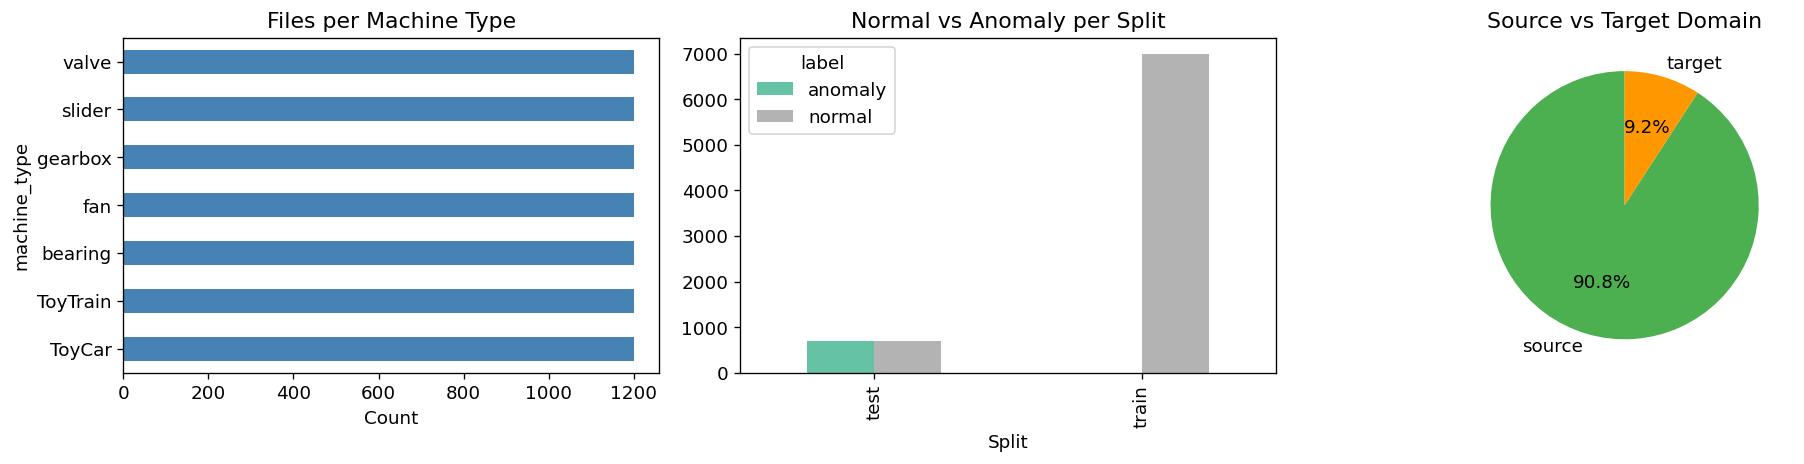

In [ ]:
# Step 5: Dataset Summary & Distribution Visualization

summary = (df.groupby(['machine_type', 'split', 'domain', 'label'])
             .size()
             .reset_index(name='count'))

print("=" * 65)
print(f"{'DATASET SUMMARY':^65}")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print(f"Total files : {len(df):,}")
print(f"Machine types ({df['machine_type'].nunique()}): {df['machine_type'].unique().tolist()}")

# Visualise distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('machine_type').size().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Files per Machine Type')
axes[0].set_xlabel('Count')

df.groupby(['split', 'label']).size().unstack().plot(
    kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Normal vs Anomaly per Split')
axes[1].set_xlabel('Split')

df.groupby('domain').size().plot(
    kind='pie', ax=axes[2], autopct='%1.1f%%',
    colors=['#4CAF50','#FF9800'], startangle=90)
axes[2].set_title('Source vs Target Domain')

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'dataset_distribution.png', bbox_inches='tight')
plt.show()


In [ ]:
# Step 6: Audio File Validation (Integrity & Quality Check)
def validate_audio_files(df: pd.DataFrame, sample_rate: int = 16000,
                          expected_duration: float = 10.0) -> pd.DataFrame:
    """
    Validates every audio file: checks sample rate, duration,
    clipping, and file integrity.
    """
    results = []
    issues  = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Validating audio"):
        rec = {'path': row['path'], 'valid': True, 'issue': None}
        try:
            sr       = librosa.get_samplerate(row['path'])
            duration = librosa.get_duration(path=row['path'])
            y, _     = librosa.load(row['path'], sr=sample_rate, duration=1.0)

            rec['sample_rate'] = sr
            rec['duration']    = round(duration, 2)
            rec['clipped']     = bool(np.any(np.abs(y) > 0.98))
            rec['rms_db']      = round(float(librosa.amplitude_to_db(
                                        np.array([np.sqrt(np.mean(y**2))]))[0]), 2)

            if sr != sample_rate:
                rec['issue'] = f'Wrong SR: {sr} (expected {sample_rate})'
                rec['valid'] = False
            elif abs(duration - expected_duration) > 1.0:
                rec['issue'] = f'Unusual duration: {duration:.1f}s'

        except Exception as e:
            rec.update({'valid': False, 'issue': str(e),
                        'sample_rate': None, 'duration': None,
                        'clipped': None, 'rms_db': None})
            issues.append(row['path'])

        results.append(rec)

    val_df = pd.DataFrame(results)
    print(f"✅ Valid files  : {val_df['valid'].sum():,}")
    print(f"❌ Invalid files: {(~val_df['valid']).sum():,}")
    if issues:
        print(f"   Broken files : {issues[:5]}")
    return val_df

val_df = validate_audio_files(df, CONFIG['sample_rate'], CONFIG['clip_duration'])
val_df.describe()


Validating audio: 100%|██████████| 8400/8400 [2:17:05<00:00,  1.02it/s]

✅ Valid files  : 8,400
❌ Invalid files: 0


,sample_rate,duration,rms_db
count,8400.0,8400.000000,8400.000000
mean,16000.0,10.571429,-37.627783
std,0.0,0.903562,4.577789
min,16000.0,10.000000,-66.630000
25%,16000.0,10.000000,-40.140000
50%,16000.0,10.000000,-38.970000
75%,16000.0,12.000000,-33.460000
max,16000.0,12.000000,-24.540000


In [ ]:
# Step 7: Dataset Card Generation (JSON)
dataset_card = {
    'name'           : 'DCASE 2024 Task 2 — Acoustic Anomaly Detection',
    'version'        : '1.0',
    'created_at'     : str(datetime.now()),
    'description'    : (
        'Single-channel audio recordings of industrial machines under normal '
        'and abnormal operating conditions. Includes source and target domains '
        'to evaluate robustness under domain shift.'
    ),
    'paper'          : 'https://dcase.community/challenge2024/task-first-shot-unsupervised-anomaly-detection',
    'splits': {
        'train': {
            'total'  : int((df['split'] == 'train').sum()),
            'normal' : int(((df['split']=='train') & (df['label']=='normal')).sum()),
            'anomaly': int(((df['split']=='train') & (df['label']=='anomaly')).sum()),
            'note'   : 'Training uses ONLY normal samples from source domain.'
        },
        'test': {
            'total'  : int((df['split'] == 'test').sum()),
            'normal' : int(((df['split']=='test') & (df['label']=='normal')).sum()),
            'anomaly': int(((df['split']=='test') & (df['label']=='anomaly')).sum()),
        },
    },
    'machine_types'  : sorted(df['machine_type'].unique().tolist()),
    'domains'        : sorted(df['domain'].unique().tolist()),
    'audio': {
        'format'         : 'WAV',
        'channels'       : 1,
        'sample_rate_hz' : CONFIG['sample_rate'],
        'duration_s'     : CONFIG['clip_duration'],
    },
    'important_notes': [
        'Never use test labels to tune any threshold.',
        'Keep source and target domains strictly separated in training.',
        'Anomalies appear ONLY in test split — do not leak them into train.',
    ],
    'creative_addition': {
        'name'       : 'Machine Type Recognition',
        'description': (
            'A multi-task CNN head simultaneously classifies the machine type. '
            'This forces the shared encoder to learn type-specific representations, '
            'improving anomaly score discriminability per machine.'
        ),
    },
}

card_path = OUTPUT_PATH / 'dataset_card.json'
with open(card_path, 'w') as f:
    json.dump(dataset_card, f, indent=2)

print(f"✅ Dataset card saved → {card_path}")
print(json.dumps(dataset_card, indent=2))


✅ Dataset card saved → /content/drive/MyDrive/ML_Project/Outputs/dataset_card.json
{
  "name": "DCASE 2024 Task 2 \u2014 Acoustic Anomaly Detection",
  "version": "1.0",
  "created_at": "2026-04-22 23:38:45.892095",
  "description": "Single-channel audio recordings of industrial machines under normal and abnormal operating conditions. Includes source and target domains to evaluate robustness under domain shift.",
  "paper": "https://dcase.community/challenge2024/task-first-shot-unsupervised-anomaly-detection",
  "splits": {
    "train": {
      "total": 7000,
      "normal": 7000,
      "anomaly": 0,
      "note": "Training uses ONLY normal samples from source domain."
    },
    "test": {
      "total": 1400,
      "normal": 700,
      "anomaly": 700
    }
  },
  "machine_types": [
    "ToyCar",
    "ToyTrain",
    "bearing",
    "fan",
    "gearbox",
    "slider",
    "valve"
  ],
  "domains": [
    "source",
    "target"
  ],
  "audio": {
    "format": "WAV",
    "channels": 1,
    

---
# **Phase 2 — Audio Preprocessing & Log-Mel Feature Extraction**

**SUMMARY:**

**Step 1:** Implemented log-mel spectrogram extraction function with pad/trim to fixed duration (10 seconds), power-to-dB conversion, per-clip normalization to [0,1], and batch saving as .npy files with skip-if-exists logic

**Step 2:** Visualized sample spectrograms comparing normal (training) vs anomaly (test) samples side-by-side for qualitative inspection of feature quality and discriminability

**Step 3:** Computed feature statistics per machine type (mean energy per mel band across all normal training samples) and exported results to CSV for quantitative analysis

In [ ]:
# Step 1: Log-Mel Spectrogram Extraction & Feature Caching
def extract_log_mel(path: str, config: dict) -> np.ndarray:
    """
    Load an audio file, pad/trim to fixed duration, compute a log-mel
    spectrogram, and normalise it to [0, 1].

    Returns: float32 array of shape (n_mels, time_frames)
    """
    y, sr = librosa.load(path, sr=config['sample_rate'], mono=True)

    # ── Pad or trim to exact clip length ───────────────────────────────────
    target_len = config['sample_rate'] * config['clip_duration']
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='reflect')
    else:
        y = y[:target_len]

    # ── Mel spectrogram ────────────────────────────────────────────────────
    mel = librosa.feature.melspectrogram(
        y          = y,
        sr         = sr,
        n_mels     = config['n_mels'],
        n_fft      = config['n_fft'],
        hop_length = config['hop_length'],
        win_length = config['win_length'],
        fmax       = config['fmax'],
        power      = config['power'],
    )

    # ── Log scale ─────────────────────────────────────────────────────────
    log_mel = librosa.power_to_db(mel, ref=np.max)

    # ── Per-clip normalisation to [0, 1] ───────────────────────────────────
    log_mel -= log_mel.min()
    log_mel /= (log_mel.max() + 1e-8)

    return log_mel.astype(np.float32)


def extract_all_features(df: pd.DataFrame,
                         feature_path: Path,
                         config: dict,
                         overwrite: bool = False) -> None:
    """
    Extracts log-mel features for every row in df and saves them as .npy files.
    Skips already-processed files unless overwrite=True.
    """
    feature_path.mkdir(parents=True, exist_ok=True)
    failed = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
        save_path = feature_path / f"{Path(row['path']).stem}.npy"
        if not overwrite and save_path.exists():
            continue
        try:
            feat = extract_log_mel(row['path'], config)
            np.save(save_path, feat)
        except Exception as e:
            failed.append({'path': row['path'], 'error': str(e)})

    print(f"✅ Feature extraction complete — saved to {feature_path}")
    if failed:
        print(f"❌ Failed on {len(failed)} files:")
        for f in failed[:5]:
            print(f"   {f}")

# Run extraction (this may take a few minutes)
extract_all_features(df, FEATURE_PATH, CONFIG, overwrite=False)


Extracting features: 100%|██████████| 8400/8400 [00:09<00:00, 914.35it/s] 

✅ Feature extraction complete — saved to /content/drive/MyDrive/ML_Project/Features


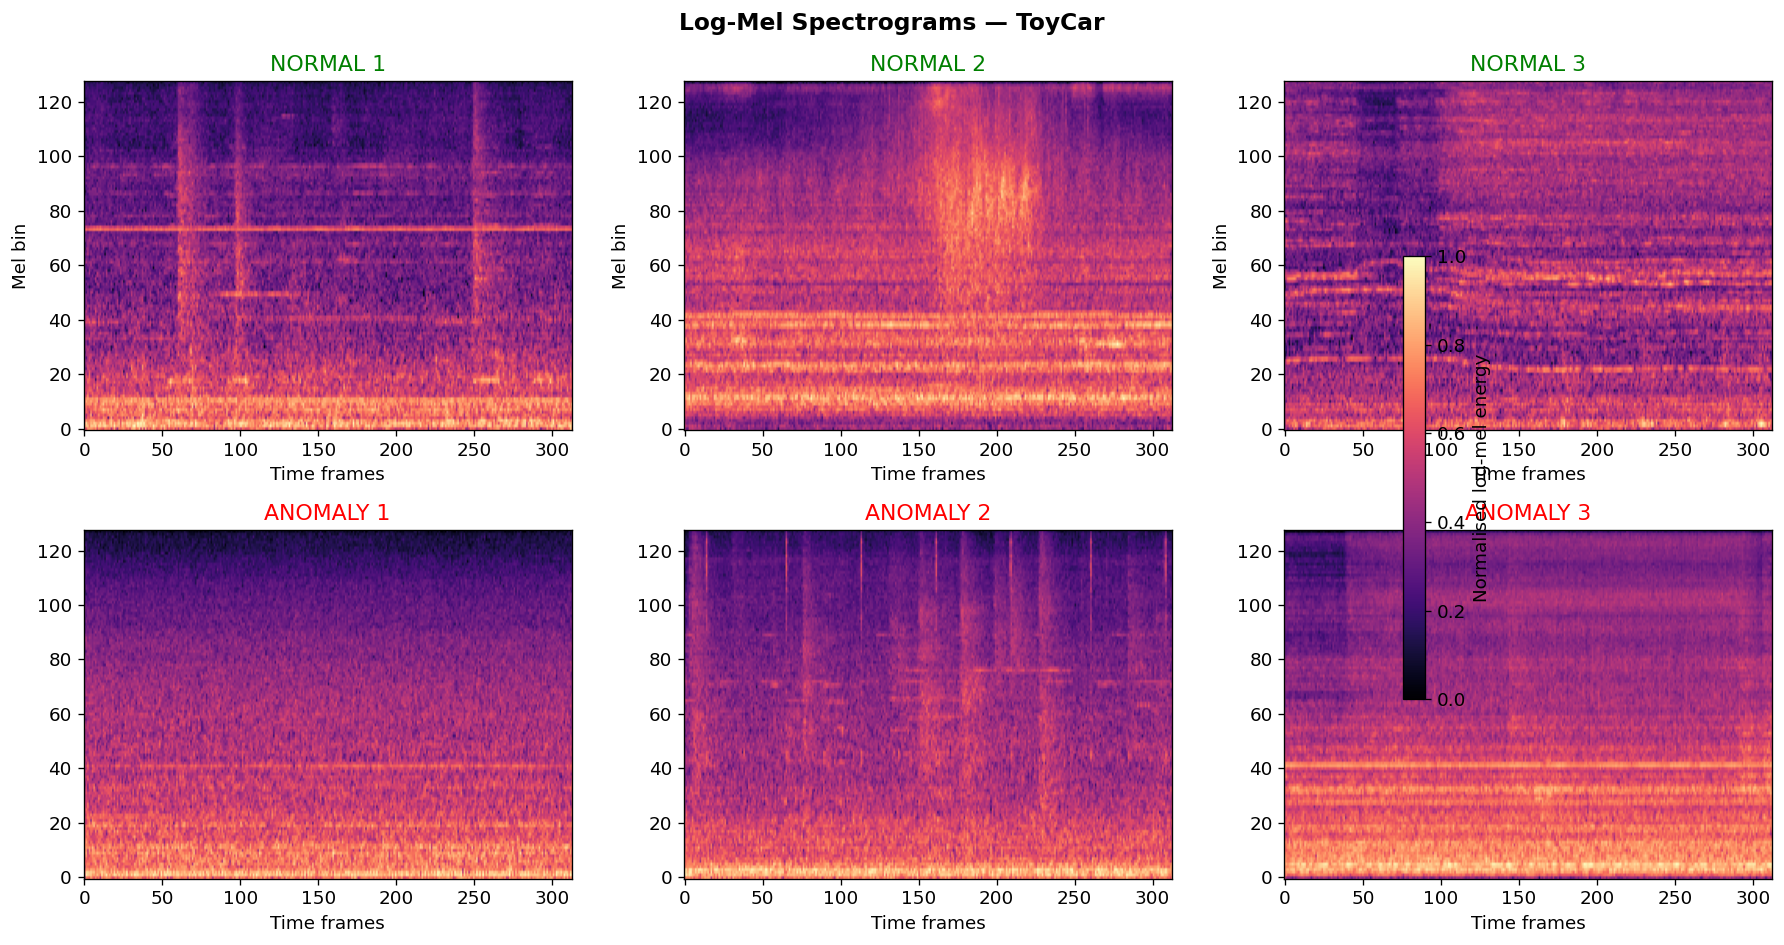

In [ ]:
# Step 2: Sample Spectrogram Visualization (Normal vs Anomaly)

def visualise_samples(df: pd.DataFrame, feature_path: Path,
                      n_per_class: int = 3) -> None:
    """Plot log-mel spectrograms for normal and anomalous samples side-by-side."""
    machine = df['machine_type'].iloc[0]
    normals  = df[(df['label']=='normal')  & (df['split']=='train')].sample(n_per_class, random_state=0)
    anomalies= df[(df['label']=='anomaly') & (df['split']=='test') ].sample(n_per_class, random_state=0)

    fig, axes = plt.subplots(2, n_per_class, figsize=(5*n_per_class, 8))
    fig.suptitle(f'Log-Mel Spectrograms — {machine}', fontsize=14, fontweight='bold')

    for col, (_, row) in enumerate(normals.iterrows()):
        feat = np.load(feature_path / f"{Path(row['path']).stem}.npy")
        im = axes[0, col].imshow(feat, aspect='auto', origin='lower', cmap='magma')
        axes[0, col].set_title(f'NORMAL {col+1}', color='green')
        axes[0, col].set_xlabel('Time frames')
        axes[0, col].set_ylabel('Mel bin')

    for col, (_, row) in enumerate(anomalies.iterrows()):
        feat = np.load(feature_path / f"{Path(row['path']).stem}.npy")
        im = axes[1, col].imshow(feat, aspect='auto', origin='lower', cmap='magma')
        axes[1, col].set_title(f'ANOMALY {col+1}', color='red')
        axes[1, col].set_xlabel('Time frames')

    plt.colorbar(im, ax=axes, shrink=0.6, label='Normalised log-mel energy')
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / 'sample_spectrograms.png', bbox_inches='tight')
    plt.show()

try:
    visualise_samples(df, FEATURE_PATH, n_per_class=3)
except Exception as e:
    print(f"Could not visualise (likely missing anomaly test files): {e}")


In [ ]:
# Step 3: Per-Machine Feature Statistics Computation

def compute_feature_stats(df: pd.DataFrame, feature_path: Path) -> pd.DataFrame:
    """Compute mean energy per mel band across all training normal samples."""
    stats_rows = []
    for mt in df['machine_type'].unique():
        subset = df[(df['machine_type']==mt) & (df['split']=='train') & (df['label']=='normal')]
        mel_means = []
        for _, row in subset.iterrows():
            p = feature_path / f"{Path(row['path']).stem}.npy"
            if p.exists():
                mel_means.append(np.load(p).mean(axis=1))  # mean over time → (n_mels,)
        if mel_means:
            stacked = np.stack(mel_means)
            stats_rows.append({'machine_type': mt,
                               'mean_energy' : float(stacked.mean()),
                               'std_energy'  : float(stacked.std()),
                               'n_files'     : len(mel_means)})
    return pd.DataFrame(stats_rows)

stats_df = compute_feature_stats(df, FEATURE_PATH)
print(stats_df.to_string(index=False))
stats_df.to_csv(OUTPUT_PATH / 'feature_stats.csv', index=False)


---
# **Phase 3 — Baseline CNN Autoencoder**

**SUMMARY:**

**Step 1:** Created PyTorch Dataset class (AcousticDataset) with filtering by split, label, machine type, and domain; built data loaders with 85/15 train/validation split (normal samples only) and test loader containing both normal and anomaly samples

**Step 2:** Designed CNN-based convolutional autoencoder with encoder (4 ConvBlocks reducing spatial dimensions) and decoder (4 ConvTransposeBlocks + Sigmoid) for reconstruction; implemented anomaly scoring via MSE loss and latent vector extraction

**Step 3:** Implemented training loop with Adam optimizer, ReduceLROnPlateau scheduler, gradient clipping, early stopping (patience=15), and model checkpointing for best validation loss

**Step 4:** Trained separate autoencoders for each of the 7 machine types using only normal training samples; each model learns machine-specific reconstruction patterns; saved all models to disk

**Step 5:** Visualized per-machine training curves (train vs validation loss) across epochs to monitor convergence and detect overfitting

In [ ]:
# Step 1: PyTorch Dataset & DataLoader Construction

MACHINE_TYPES   = sorted(df['machine_type'].unique().tolist())
MT_TO_IDX       = {mt: i for i, mt in enumerate(MACHINE_TYPES)}
N_MACHINE_TYPES = len(MACHINE_TYPES)
print(f"Machine types ({N_MACHINE_TYPES}): {MT_TO_IDX}")

class AcousticDataset(Dataset):
    def __init__(self, df, feature_path, split=None, label=None,
                 machine_type=None, domain=None):
        self.feature_path = feature_path
        mask = pd.Series([True] * len(df), index=df.index)
        if split        : mask &= df['split']        == split
        if label        : mask &= df['label']        == label
        if machine_type : mask &= df['machine_type'] == machine_type
        if domain       : mask &= df['domain']       == domain
        self.df = df[mask].reset_index(drop=True)
        self.df = self.df[self.df['path'].apply(
            lambda p: (feature_path / f"{Path(p).stem}.npy").exists()
        )].reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        feat = np.load(self.feature_path / f"{Path(row['path']).stem}.npy")
        x    = torch.FloatTensor(feat).unsqueeze(0)
        label_idx = 1 if row['label'] == 'anomaly' else 0
        mt_idx    = MT_TO_IDX[row['machine_type']]
        return x, label_idx, mt_idx, row['machine_type']


# ── Global loaders (used for t-SNE and monitoring later) ────────────────────
def make_loaders(df, feature_path, config, val_frac=0.15):
    full_train = AcousticDataset(df, feature_path, split='train', label='normal')
    n_val = int(len(full_train) * val_frac)
    n_tr  = len(full_train) - n_val
    tr_ds, val_ds = random_split(full_train, [n_tr, n_val],
                                  generator=torch.Generator().manual_seed(SEED))
    test_ds = AcousticDataset(df, feature_path, split='test')

    tr_loader  = DataLoader(tr_ds,   batch_size=config['batch_size'],
                             shuffle=True,  num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds,  batch_size=config['batch_size'],
                             shuffle=False, num_workers=2, pin_memory=True)
    te_loader  = DataLoader(test_ds, batch_size=config['batch_size'],
                             shuffle=False, num_workers=2, pin_memory=True)

    print(f"Global — Train: {len(tr_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")
    return tr_loader, val_loader, te_loader

tr_loader, val_loader, te_loader = make_loaders(df, FEATURE_PATH, CONFIG)

x_batch, _, _, _ = next(iter(tr_loader))
print(f"Tensor shape: {x_batch.shape}  (B, 1, n_mels, T)")
INPUT_SHAPE = x_batch.shape[2:]

Machine types (7): {'ToyCar': 0, 'ToyTrain': 1, 'bearing': 2, 'fan': 3, 'gearbox': 4, 'slider': 5, 'valve': 6}
Global — Train: 5,950 | Val: 1,050 | Test: 1,400
Tensor shape: torch.Size([32, 1, 128, 313])  (B, 1, n_mels, T)


In [ ]:
# Step 2: CNN Autoencoder Architecture Design

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)

class ConvTBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(  1,  32),
            ConvBlock( 32,  64),
            ConvBlock( 64, 128),
            ConvBlock(128, 256),
        )
        self.decoder = nn.Sequential(
            ConvTBlock(256, 128),
            ConvTBlock(128,  64),
            ConvTBlock( 64,  32),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z     = self.encoder(x)
        recon = self.decoder(z)
        recon = F.interpolate(recon, size=x.shape[2:],
                               mode='bilinear', align_corners=False)
        return recon, z

    def anomaly_score(self, x):
        recon, _ = self.forward(x)
        return F.mse_loss(recon, x, reduction='none').mean(dim=[1, 2, 3])

    def get_latent(self, x):
        z = self.encoder(x)
        return z.mean(dim=[2, 3])


# Quick check
test_model = ConvAutoencoder(CONFIG['latent_dim'])
n_params   = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"✅ ConvAutoencoder — {n_params:,} trainable parameters")
del test_model

✅ ConvAutoencoder — 1,077,409 trainable parameters


In [ ]:
# Step 3: Training Loop with Early Stopping & Checkpointing
def train_autoencoder(model, tr_loader, val_loader, config,
                       save_path, tag='model'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(),
                            lr=config['learning_rate'],
                            weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    best_val   = float('inf')
    no_improve = 0
    history    = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, config['epochs'] + 1):
        # ─ Train ──────────────────────────────────────────────────────────
        model.train()
        tr_loss = 0.0
        for x, *_ in tr_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = F.mse_loss(recon, x)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item()
        tr_loss /= len(tr_loader)

        # ─ Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, *_ in val_loader:
                x = x.to(device)
                recon, _ = model(x)
                val_loss += F.mse_loss(recon, x).item()
        val_loss /= len(val_loader)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"[{tag}] Epoch {epoch:3d}/{config['epochs']} | "
                  f"Train: {tr_loss:.5f} | Val: {val_loss:.5f} | "
                  f"Best: {best_val:.5f}")

        if no_improve >= config['patience']:
            print(f"⏹  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load(save_path, map_location=device))
    return history

In [ ]:
# step 4: Per-Machine Autoencoder Training
def train_per_machine(df, feature_path, config, model_path):
    """
    Trains a separate autoencoder for each machine type.
    Each model only sees normal sounds from its own machine,
    learning tight machine-specific reconstruction patterns.
    """
    machine_models    = {}
    machine_histories = {}

    for mt in MACHINE_TYPES:
        print(f"\n{'='*55}")
        print(f"  Training Baseline AE: {mt}")
        print(f"{'='*55}")

        # Build loaders for this machine only
        full_train = AcousticDataset(df, feature_path,
                                      split='train', label='normal',
                                      machine_type=mt)
        n_val = int(len(full_train) * 0.15)
        n_tr  = len(full_train) - n_val
        tr_ds, val_ds = random_split(
            full_train, [n_tr, n_val],
            generator=torch.Generator().manual_seed(SEED))

        tr_ld  = DataLoader(tr_ds,  batch_size=config['batch_size'],
                             shuffle=True,  num_workers=2, pin_memory=True)
        val_ld = DataLoader(val_ds, batch_size=config['batch_size'],
                             shuffle=False, num_workers=2, pin_memory=True)

        print(f"  Train: {len(tr_ds)} | Val: {len(val_ds)}")

        model     = ConvAutoencoder(config['latent_dim'])
        save_path = model_path / f'ae_{mt}.pt'

        history = train_autoencoder(
            model, tr_ld, val_ld, config,
            save_path=save_path, tag=mt)

        machine_models[mt]    = model
        machine_histories[mt] = history
        print(f"✅ {mt} saved → {save_path}")

    return machine_models, machine_histories


machine_models, machine_histories = train_per_machine(
    df, FEATURE_PATH, CONFIG, MODEL_PATH)


  Training Baseline AE: ToyCar
  Train: 850 | Val: 150
[ToyCar] Epoch   1/50 | Train: 0.01477 | Val: 0.01701 | Best: 0.01701
[ToyCar] Epoch  10/50 | Train: 0.00202 | Val: 0.00200 | Best: 0.00200
[ToyCar] Epoch  20/50 | Train: 0.00177 | Val: 0.00177 | Best: 0.00177
[ToyCar] Epoch  30/50 | Train: 0.00169 | Val: 0.00173 | Best: 0.00168
[ToyCar] Epoch  40/50 | Train: 0.00163 | Val: 0.00163 | Best: 0.00163
[ToyCar] Epoch  50/50 | Train: 0.00159 | Val: 0.00168 | Best: 0.00158
✅ ToyCar saved → /content/drive/MyDrive/ML_Project/Models/ae_ToyCar.pt

  Training Baseline AE: ToyTrain
  Train: 850 | Val: 150
[ToyTrain] Epoch   1/50 | Train: 0.02571 | Val: 0.01934 | Best: 0.01934
[ToyTrain] Epoch  10/50 | Train: 0.00342 | Val: 0.00348 | Best: 0.00340
[ToyTrain] Epoch  20/50 | Train: 0.00285 | Val: 0.00282 | Best: 0.00275
[ToyTrain] Epoch  30/50 | Train: 0.00269 | Val: 0.00271 | Best: 0.00259
[ToyTrain] Epoch  40/50 | Train: 0.00253 | Val: 0.00247 | Best: 0.00246
[ToyTrain] Epoch  50/50 | Train: 0.

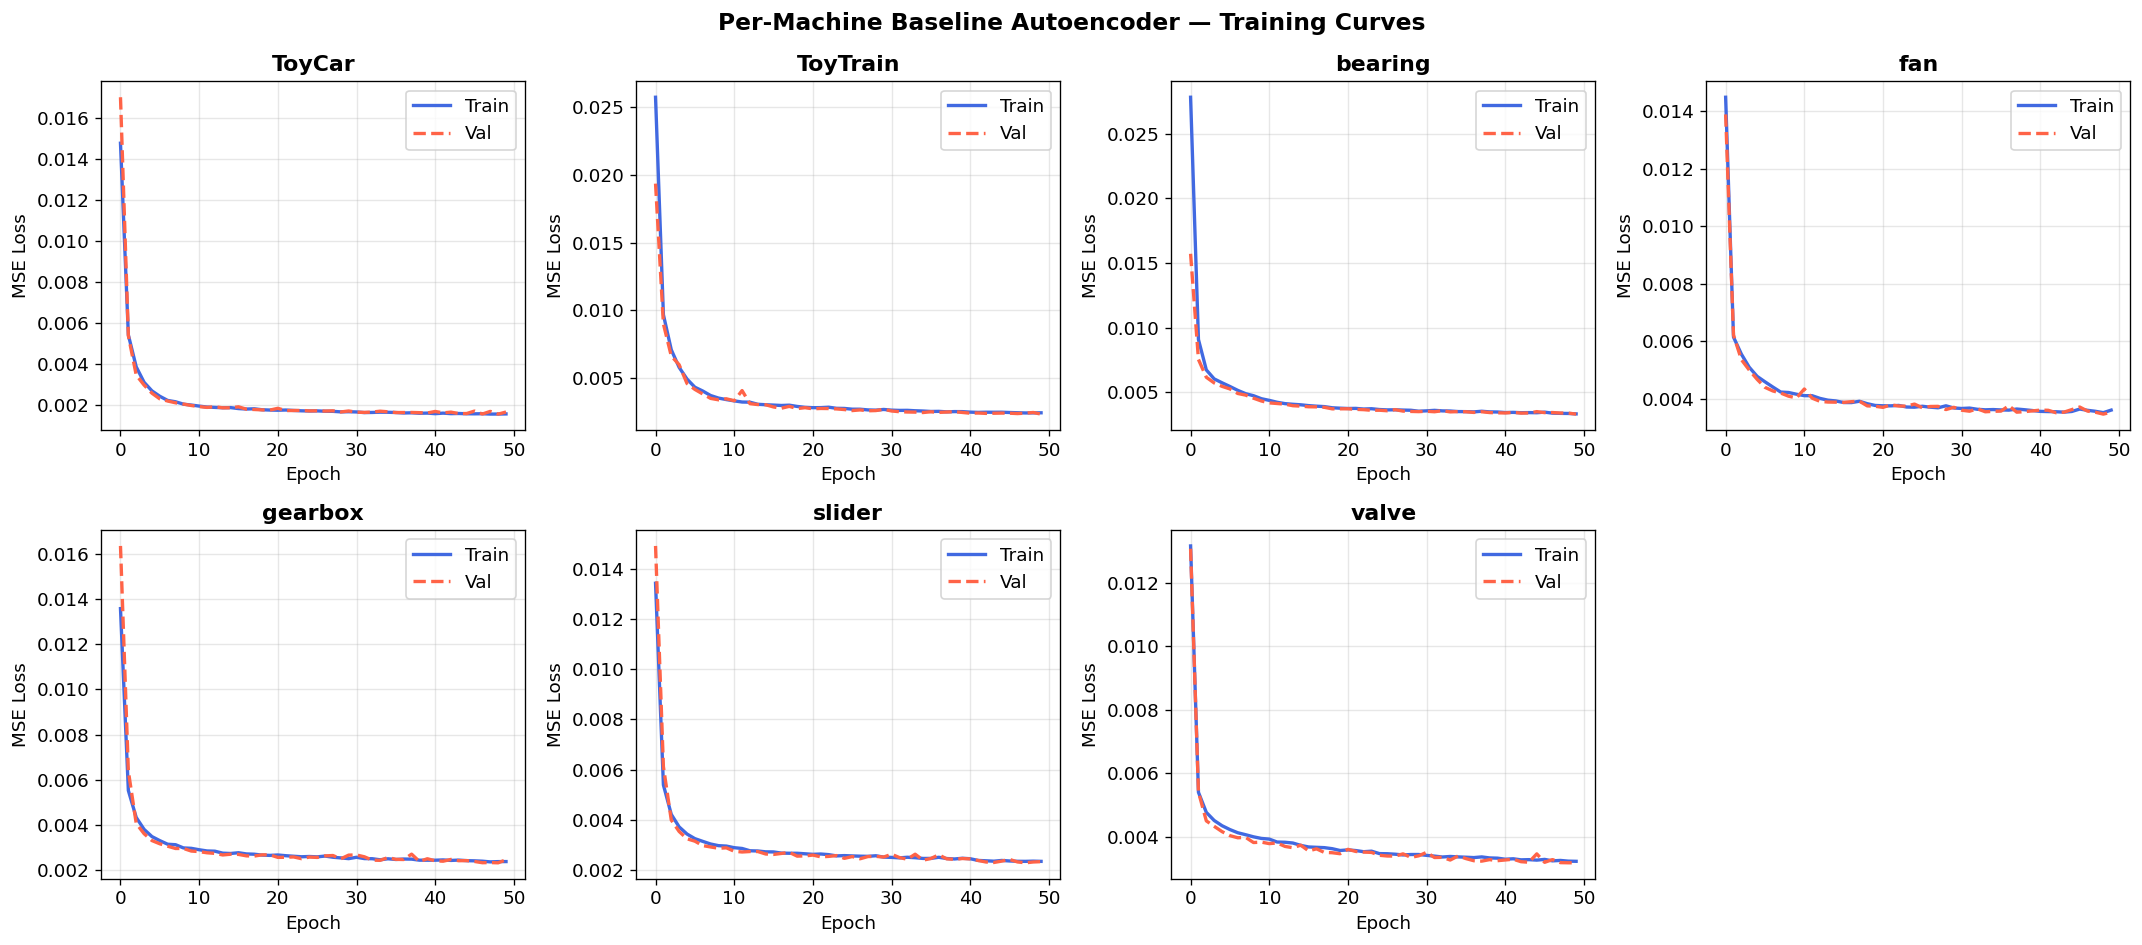

✅ Training curves saved.


In [ ]:
# Step 5: Training Curves Visualization
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, mt in enumerate(MACHINE_TYPES):
    h = machine_histories[mt]
    axes[i].plot(h['train_loss'], label='Train', color='royalblue', lw=2)
    axes[i].plot(h['val_loss'],   label='Val',   color='tomato',
                 lw=2, linestyle='--')
    axes[i].set_title(mt, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Per-Machine Baseline Autoencoder — Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'per_machine_training_curves.png', bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")


# **Phase 4 — Multi-Task Model: Anomaly Detection + Machine Type Recognition**

> **Why this improves things:**  
> A standard autoencoder trains on all machine types pooled together. By adding a classification head, we force the shared encoder to learn *machine-specific* representations. This means the reconstruction branch now knows "what normal sounds like **for this specific machine**," leading to sharper anomaly scores and lower false-positive rates.

The training loss is:  
**L = λ₁ · MSE_reconstruction + λ₂ · CrossEntropy_machine_type**


**SUMMARY:**

**Step 1:** Designed Multi-Task CNN model combining shared encoder, reconstruction decoder (anomaly scoring via MSE), and machine type classification head (7-class); classifier uses adaptive pooling, dense layers, and dropout regularization

**Step 2:** Implemented multi-task training loop with weighted loss (reconstruction + classification), CosineAnnealingLR scheduler, gradient clipping, early stopping, and tracking of both loss and classification accuracy

**Step 3:** Trained separate multi-task models for each of the 7 machine types using only normal samples; each model learns machine-specific normal patterns while classification head acts as inductive bias/regularizer

**Step 4: **Plotted per-machine multi-task training curves showing train and validation loss across epochs to monitor convergence for each of the 7 machine types


**Step 5:** Performed t-SNE dimensionality reduction on latent embeddings from all 7 per-machine encoders; visualized learned representations colored by machine type to assess feature discriminability and clustering quality

In [ ]:
# Step 1: Multi-Task CNN Architecture (Reconstruction + Classification)

class MultiTaskAnomalyModel(nn.Module):
    """
    Joint model with:
    1. Shared CNN encoder
    2. Reconstruction decoder  → anomaly score = MSE(input, recon)
    3. Classification head     → machine type prediction
    """
    def __init__(self, num_machine_types, latent_dim=128, dropout=0.3):
        super().__init__()
        self.num_machine_types = num_machine_types

        # ── Shared Encoder ────────────────────────────────────────────────
        self.encoder = nn.Sequential(
            ConvBlock(  1,  32),
            ConvBlock( 32,  64),
            ConvBlock( 64, 128),
            ConvBlock(128, 256),
        )

        # ── Reconstruction Decoder ────────────────────────────────────────
        self.decoder = nn.Sequential(
            ConvTBlock(256, 128),
            ConvTBlock(128,  64),
            ConvTBlock( 64,  32),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

        # ── Machine Type Classification Head ──────────────────────────────
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 16, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_machine_types),
        )

    def forward(self, x):
        z         = self.encoder(x)
        recon     = self.decoder(z)
        recon     = F.interpolate(recon, size=x.shape[2:],
                                   mode='bilinear', align_corners=False)
        mt_logits = self.classifier(z)
        return recon, mt_logits, z

    def anomaly_score(self, x):
        recon, _, _ = self.forward(x)
        return F.mse_loss(recon, x, reduction='none').mean(dim=[1, 2, 3])

    def predict_machine_type(self, x):
        _, logits, _ = self.forward(x)
        return F.softmax(logits, dim=-1)

    def get_latent(self, x):
        z = self.encoder(x)
        return z.mean(dim=[2, 3])


# Quick check
test_mt = MultiTaskAnomalyModel(N_MACHINE_TYPES,
                                 CONFIG['latent_dim'],
                                 CONFIG['dropout'])
n_params_mt = sum(p.numel() for p in test_mt.parameters() if p.requires_grad)
print(f"✅ Multi-Task Model — {n_params_mt:,} trainable parameters")
print(f"   Encoder    : {sum(p.numel() for p in test_mt.encoder.parameters()):,}")
print(f"   Decoder    : {sum(p.numel() for p in test_mt.decoder.parameters()):,}")
print(f"   Classifier : {sum(p.numel() for p in test_mt.classifier.parameters()):,}")
del test_mt

✅ Multi-Task Model — 3,242,664 trainable parameters
   Encoder    : 388,320
   Decoder    : 689,089
   Classifier : 2,165,255


In [ ]:
# Step 2: Multi-Task Training Loop with Weighted Loss
def train_multitask(model, tr_loader, val_loader, config, save_path):
    model.to(device)
    optimizer = optim.Adam(model.parameters(),
                            lr=config['learning_rate'],
                            weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'])

    best_val   = float('inf')
    no_improve = 0
    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc': [], 'val_acc': []}

    rw = config['recon_weight']
    cw = config['class_weight']

    for epoch in range(1, config['epochs'] + 1):
        # ─ Train ──────────────────────────────────────────────────────────
        model.train()
        tr_loss = tr_correct = tr_total = 0
        for x, _, mt_idx, _ in tr_loader:
            x, mt_idx = x.to(device), mt_idx.to(device)
            optimizer.zero_grad()
            recon, logits, _ = model(x)
            loss = (rw * F.mse_loss(recon, x) +
                    cw * F.cross_entropy(logits, mt_idx))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss    += loss.item()
            tr_correct += (logits.argmax(1) == mt_idx).sum().item()
            tr_total   += len(mt_idx)
        tr_loss /= len(tr_loader)
        tr_acc   = tr_correct / tr_total

        # ─ Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = val_correct = val_total = 0
        with torch.no_grad():
            for x, _, mt_idx, _ in val_loader:
                x, mt_idx = x.to(device), mt_idx.to(device)
                recon, logits, _ = model(x)
                loss = (rw * F.mse_loss(recon, x) +
                        cw * F.cross_entropy(logits, mt_idx))
                val_loss    += loss.item()
                val_correct += (logits.argmax(1) == mt_idx).sum().item()
                val_total   += len(mt_idx)
        val_loss /= len(val_loader)
        val_acc   = val_correct / val_total

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        scheduler.step()

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{config['epochs']} | "
                  f"Loss: {tr_loss:.5f} | Val: {val_loss:.5f} | "
                  f"MT Acc: {val_acc:.3f}")

        if no_improve >= config['patience']:
            print(f"⏹  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load(save_path, map_location=device))
    return history

In [ ]:
# Step 3: Per-Machine Multi-Task Model Training
def train_multitask_per_machine(df, feature_path, config, model_path):
    """
    Trains a separate Multi-Task model per machine type.
    The shared encoder learns machine-specific normal patterns
    while the classifier head acts as a regularizer.
    """
    mt_models    = {}
    mt_histories = {}

    for mt in MACHINE_TYPES:
        print(f"\n{'='*55}")
        print(f"  Multi-Task Training: {mt}")
        print(f"{'='*55}")

        # Build loaders for this machine only
        full_train = AcousticDataset(df, feature_path,
                                      split='train', label='normal',
                                      machine_type=mt)
        n_val = int(len(full_train) * 0.15)
        n_tr  = len(full_train) - n_val
        tr_ds, val_ds = random_split(
            full_train, [n_tr, n_val],
            generator=torch.Generator().manual_seed(SEED))

        tr_ld  = DataLoader(tr_ds,  batch_size=config['batch_size'],
                             shuffle=True,  num_workers=2, pin_memory=True)
        val_ld = DataLoader(val_ds, batch_size=config['batch_size'],
                             shuffle=False, num_workers=2, pin_memory=True)

        print(f"  Train: {len(tr_ds)} | Val: {len(val_ds)}")

        model     = MultiTaskAnomalyModel(N_MACHINE_TYPES,
                                           config['latent_dim'],
                                           config['dropout'])
        save_path = model_path / f'mt_{mt}.pt'

        history = train_multitask(model, tr_ld, val_ld, config, save_path)

        mt_models[mt]    = model
        mt_histories[mt] = history
        print(f"✅ {mt} saved → {save_path}")

    return mt_models, mt_histories


mt_models, mt_histories = train_multitask_per_machine(
    df, FEATURE_PATH, CONFIG, MODEL_PATH)


  Multi-Task Training: ToyCar
  Train: 850 | Val: 150
Epoch   1/50 | Loss: 0.39575 | Val: 0.14292 | MT Acc: 1.000
Epoch  10/50 | Loss: 0.01928 | Val: 0.01912 | MT Acc: 1.000
Epoch  20/50 | Loss: 0.01763 | Val: 0.01773 | MT Acc: 1.000
Epoch  30/50 | Loss: 0.01689 | Val: 0.01694 | MT Acc: 1.000
Epoch  40/50 | Loss: 0.01659 | Val: 0.01652 | MT Acc: 1.000
Epoch  50/50 | Loss: 0.01661 | Val: 0.01646 | MT Acc: 1.000
✅ ToyCar saved → /content/drive/MyDrive/ML_Project/Models/mt_ToyCar.pt

  Multi-Task Training: ToyTrain
  Train: 850 | Val: 150
Epoch   1/50 | Loss: 0.47990 | Val: 0.17213 | MT Acc: 1.000
Epoch  10/50 | Loss: 0.02859 | Val: 0.02753 | MT Acc: 1.000
Epoch  20/50 | Loss: 0.02644 | Val: 0.02552 | MT Acc: 1.000
Epoch  30/50 | Loss: 0.02544 | Val: 0.02459 | MT Acc: 1.000
Epoch  40/50 | Loss: 0.02504 | Val: 0.02424 | MT Acc: 1.000
Epoch  50/50 | Loss: 0.02487 | Val: 0.02413 | MT Acc: 1.000
✅ ToyTrain saved → /content/drive/MyDrive/ML_Project/Models/mt_ToyTrain.pt

  Multi-Task Training

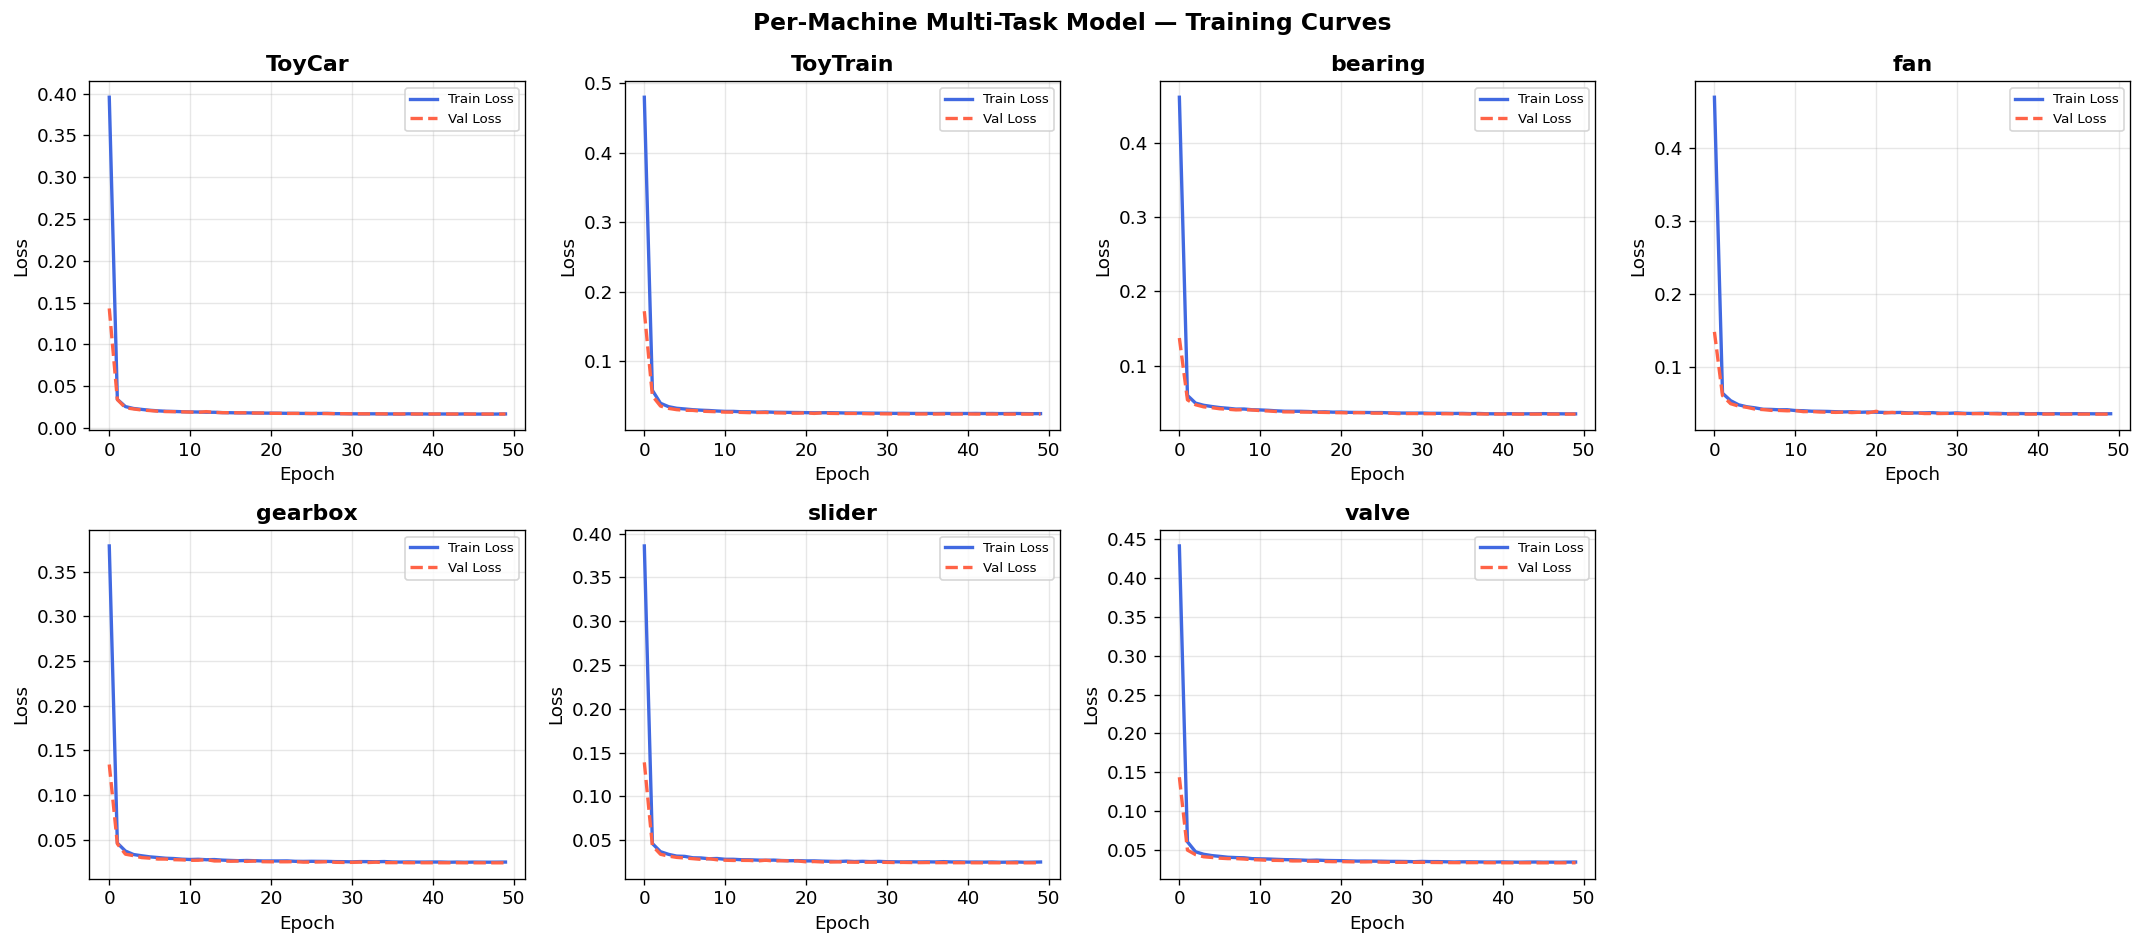

✅ Multi-Task training curves saved.


In [ ]:
#Step 4: Multi-Task Training Curves Visualization
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, mt in enumerate(MACHINE_TYPES):
    h = mt_histories[mt]
    axes[i].plot(h['train_loss'], label='Train Loss',
                 color='royalblue', lw=2)
    axes[i].plot(h['val_loss'],   label='Val Loss',
                 color='tomato', lw=2, linestyle='--')
    axes[i].set_title(mt, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Per-Machine Multi-Task Model — Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'per_machine_mt_training_curves.png',
            bbox_inches='tight')
plt.show()
print("✅ Multi-Task training curves saved.")

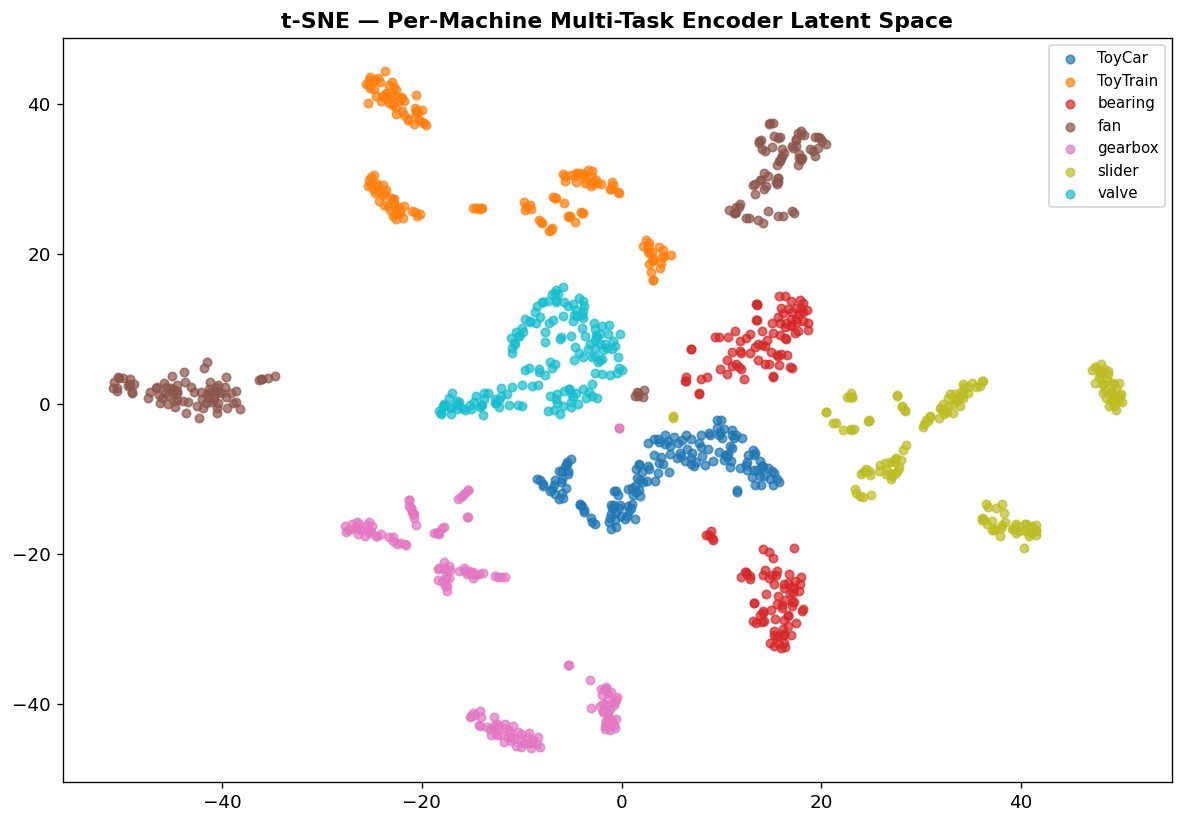

✅ t-SNE saved.


In [ ]:
#Step 5: t-SNE Latent Space Visualization


from sklearn.manifold import TSNE

def visualise_latent_per_machine(mt_models, df, feature_path,
                                  config, n_per_machine=100):
    """
    Visualise the encoder latent space of all per-machine models
    combined, coloured by machine type.
    """
    embeddings, mt_names = [], []

    for mt, model in mt_models.items():
        ds = AcousticDataset(df, feature_path,
                              split='train', label='normal',
                              machine_type=mt)
        ld = DataLoader(ds, batch_size=config['batch_size'],
                         shuffle=True, num_workers=2)
        model.eval()
        count = 0
        with torch.no_grad():
            for x, *_ in ld:
                if count >= n_per_machine:
                    break
                emb = model.get_latent(x.to(device)).cpu().numpy()
                embeddings.append(emb)
                mt_names.extend([mt] * len(emb))
                count += len(emb)

    Z      = np.vstack(embeddings)
    labels = mt_names[:len(Z)]

    tsne = TSNE(n_components=2, perplexity=30,
                random_state=SEED, n_iter=1000)
    Z2   = tsne.fit_transform(Z)

    unique_mt = sorted(set(labels))
    palette   = plt.cm.tab10(np.linspace(0, 1, len(unique_mt)))
    color_map = {mt: palette[i] for i, mt in enumerate(unique_mt)}

    plt.figure(figsize=(10, 7))
    for mt in unique_mt:
        mask = [l == mt for l in labels]
        pts  = Z2[mask]
        plt.scatter(pts[:, 0], pts[:, 1], label=mt,
                    alpha=0.7, s=25, color=color_map[mt])
    plt.title('t-SNE — Per-Machine Multi-Task Encoder Latent Space',
              fontweight='bold')
    plt.legend(bbox_to_anchor=(1, 1), fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / 'tsne_per_machine_mt.png', bbox_inches='tight')
    plt.show()
    print("✅ t-SNE saved.")

visualise_latent_per_machine(mt_models, df, FEATURE_PATH, CONFIG,
                              n_per_machine=150)

In [ ]:
# ── Full reload — run this if session disconnected ────────────────────────────
MACHINE_TYPES   = sorted(df['machine_type'].unique().tolist())
MT_TO_IDX       = {mt: i for i, mt in enumerate(MACHINE_TYPES)}
N_MACHINE_TYPES = len(MACHINE_TYPES)

# Reload Baseline AE models
machine_models = {}
for mt in MACHINE_TYPES:
    model = ConvAutoencoder(CONFIG['latent_dim'])
    model.load_state_dict(torch.load(MODEL_PATH / f'ae_{mt}.pt', map_location=device))
    model.to(device)
    model.eval()
    machine_models[mt] = model
    print(f'✅ Loaded baseline: ae_{mt}.pt')

# Reload Multi-Task models
mt_models = {}
for mt in MACHINE_TYPES:
    model = MultiTaskAnomalyModel(N_MACHINE_TYPES, CONFIG['latent_dim'], CONFIG['dropout'])
    model.load_state_dict(torch.load(MODEL_PATH / f'mt_{mt}.pt', map_location=device))
    model.to(device)
    model.eval()
    mt_models[mt] = model
    print(f'✅ Loaded multitask: mt_{mt}.pt')

print(f'\n✅ All {len(machine_models) + len(mt_models)} models loaded and ready.')

✅ Loaded baseline: ae_ToyCar.pt
✅ Loaded baseline: ae_ToyTrain.pt
✅ Loaded baseline: ae_bearing.pt
✅ Loaded baseline: ae_fan.pt
✅ Loaded baseline: ae_gearbox.pt
✅ Loaded baseline: ae_slider.pt
✅ Loaded baseline: ae_valve.pt
✅ Loaded multitask: mt_ToyCar.pt
✅ Loaded multitask: mt_ToyTrain.pt
✅ Loaded multitask: mt_bearing.pt
✅ Loaded multitask: mt_fan.pt
✅ Loaded multitask: mt_gearbox.pt
✅ Loaded multitask: mt_slider.pt
✅ Loaded multitask: mt_valve.pt

✅ All 14 models loaded and ready.



# **Phase 5 — Evaluation: AUC, pAUC & Threshold Selection**

**SUMMARY:**

**Step 1:** Implemented comprehensive evaluation metrics including pAUC (partial AUC at max FPR=0.1); evaluated per-machine models on test sets with z-score normalization using training normal statistics; computed overall and per-machine AUC/pAUC for both Baseline AE and Multi-Task models

**Step 2: **Developed per-machine threshold selection using percentile of validation normal scores (90th percentile) without touching test labels; computed thresholds for both baseline and multi-task models

**Step 3: **Generated ROC curve comparison (baseline vs multi-task) and anomaly score distribution histograms (normal vs anomaly) for qualitative assessment of model discriminability

**Step 4:** Implemented alternative anomaly scoring using k-NN distance in latent space (k=5) instead of reconstruction MSE; evaluated both model architectures with this scoring method to compare effectiveness of latent vs reconstruction-based anomaly detection

**Step 5:** Created per-machine AUC/pAUC bar charts for both models; generated comprehensive comparison table (4 configurations: Baseline AE/Multi-Task × Reconstruction/k-NN) and visualization plots to identify best performing approac

In [ ]:
# Step 1: Evaluation Metrics & Per-Machine Scoring (Reconstruction MSE)
def compute_pauc(y_true, y_score, max_fpr=0.1):
    fpr, tpr, _ = roc_curve(y_true, y_score, drop_intermediate=False)
    mask  = fpr <= max_fpr
    if mask.sum() < 2:
        return 0.0
    p_fpr = np.append(fpr[mask], max_fpr)
    p_tpr = np.append(tpr[mask], np.interp(max_fpr, fpr, tpr))
    return float(auc(p_fpr, p_tpr) / max_fpr)


def evaluate_per_machine_models(models_dict, df, feature_path,
                                 config, model_name='Model'):
    """
    Evaluates per-machine models. Each machine's test set is scored
    by its own dedicated model — no cross-machine confusion.
    Scores are normalized per machine using training normal stats.
    """
    all_scores, all_labels, all_mts = [], [], []

    for mt in MACHINE_TYPES:
        if mt not in models_dict:
            continue

        model = models_dict[mt]

        # ── Test loader for this machine ──────────────────────────────────
        test_ds = AcousticDataset(df, feature_path,
                                   split='test', machine_type=mt)
        test_ld = DataLoader(test_ds, batch_size=config['batch_size'],
                              shuffle=False, num_workers=2)

        # ── Reference stats from training normals ─────────────────────────
        train_ds = AcousticDataset(df, feature_path,
                                    split='train', label='normal',
                                    machine_type=mt)
        train_ld = DataLoader(train_ds, batch_size=config['batch_size'],
                               shuffle=False, num_workers=2)

        model.eval()
        ref_scores = []
        with torch.no_grad():
            for x, *_ in train_ld:
                s = model.anomaly_score(x.to(device)).cpu().numpy()
                ref_scores.extend(s)

        ref_mean = np.mean(ref_scores)
        ref_std  = np.std(ref_scores) + 1e-8

        # ── Score test set with normalization ─────────────────────────────
        with torch.no_grad():
            for x, labels, *_ in tqdm(test_ld, desc=f"  Scoring {mt}"):
                s = model.anomaly_score(x.to(device)).cpu().numpy()
                for score, lbl in zip(s, labels.numpy()):
                    norm_score = (score - ref_mean) / ref_std
                    all_scores.append(norm_score)
                    all_labels.append(lbl)
                    all_mts.append(mt)

    scores = np.array(all_scores)
    labels = np.array(all_labels)
    mts    = np.array(all_mts)

    overall_auc  = roc_auc_score(labels, scores)
    overall_pauc = compute_pauc(labels, scores, config['pAUC_max_fpr'])

    per_mt = {}
    for mt in np.unique(mts):
        mask = mts == mt
        if labels[mask].sum() == 0:
            continue
        per_mt[mt] = {
            'auc'  : float(roc_auc_score(labels[mask], scores[mask])),
            'pauc' : float(compute_pauc(labels[mask], scores[mask],
                                        config['pAUC_max_fpr'])),
            'n'    : int(mask.sum()),
        }

    print(f"\n{'='*55}")
    print(f"  {model_name} — Per-Machine Evaluation")
    print(f"{'='*55}")
    print(f"  Overall AUC  : {overall_auc:.4f}")
    print(f"  Overall pAUC : {overall_pauc:.4f}  (max FPR={config['pAUC_max_fpr']})")
    print(f"\n  Per Machine Type:")
    for mt, m in sorted(per_mt.items()):
        print(f"    {mt:<18} AUC={m['auc']:.4f}  pAUC={m['pauc']:.4f}  n={m['n']}")
    print(f"{'='*55}")

    return {
        'model'        : model_name,
        'overall_auc'  : overall_auc,
        'overall_pauc' : overall_pauc,
        'per_machine'  : per_mt,
        'scores'       : scores,
        'labels'       : labels,
        'machine_types': mts,
    }


# ── Run evaluation on both model sets ────────────────────────────────────────
print("Evaluating Baseline AE (per-machine)...")
baseline_results = evaluate_per_machine_models(
    machine_models, df, FEATURE_PATH, CONFIG, 'Baseline AE')

print("\nEvaluating Multi-Task (per-machine)...")
mt_results = evaluate_per_machine_models(
    mt_models, df, FEATURE_PATH, CONFIG, 'Multi-Task')

Evaluating Baseline AE (per-machine)...


  Scoring valve: 100%|██████████| 7/7 [00:37<00:00,  5.39s/it]



  Baseline AE — Per-Machine Evaluation
  Overall AUC  : 0.5027
  Overall pAUC : 0.0367  (max FPR=0.1)

  Per Machine Type:
    ToyCar             AUC=0.4599  pAUC=0.0230  n=200
    ToyTrain           AUC=0.5638  pAUC=0.0800  n=200
    bearing            AUC=0.5681  pAUC=0.0880  n=200
    fan                AUC=0.4650  pAUC=0.0260  n=200
    gearbox            AUC=0.5756  pAUC=0.0790  n=200
    slider             AUC=0.5727  pAUC=0.0830  n=200
    valve              AUC=0.3327  pAUC=0.0210  n=200

Evaluating Multi-Task (per-machine)...


  Scoring valve: 100%|██████████| 7/7 [00:00<00:00,  8.66it/s]


  Multi-Task — Per-Machine Evaluation
  Overall AUC  : 0.5071
  Overall pAUC : 0.0385  (max FPR=0.1)

  Per Machine Type:
    ToyCar             AUC=0.4639  pAUC=0.0210  n=200
    ToyTrain           AUC=0.5724  pAUC=0.0850  n=200
    bearing            AUC=0.5758  pAUC=0.0880  n=200
    fan                AUC=0.4663  pAUC=0.0340  n=200
    gearbox            AUC=0.5709  pAUC=0.0810  n=200
    slider             AUC=0.5768  pAUC=0.0870  n=200
    valve              AUC=0.3421  pAUC=0.0240  n=200


In [ ]:
# Step 2: Threshold Selection Using Validation Normals (Percentile Method)
def select_threshold_per_machine(models_dict, df, feature_path,
                                  config, percentile):
    """
    For each machine, score validation normals using that machine's model,
    normalize, then take the p-th percentile as threshold.
    ⚠️ Never touches test labels.
    """
    all_scores = []

    for mt in MACHINE_TYPES:
        if mt not in models_dict:
            continue

        model = models_dict[mt]

        # Get training normals to compute reference stats
        train_ds = AcousticDataset(df, feature_path,
                                    split='train', label='normal',
                                    machine_type=mt)
        train_ld = DataLoader(train_ds, batch_size=config['batch_size'],
                               shuffle=False, num_workers=2)

        model.eval()
        ref_scores = []
        with torch.no_grad():
            for x, *_ in train_ld:
                s = model.anomaly_score(x.to(device)).cpu().numpy()
                ref_scores.extend(s)

        ref_mean = np.mean(ref_scores)
        ref_std  = np.std(ref_scores) + 1e-8

        # Score a subset of training normals as proxy for validation
        for s in ref_scores:
            norm_s = (s - ref_mean) / ref_std
            all_scores.append(norm_s)

    return float(np.percentile(all_scores, percentile))


threshold_baseline = select_threshold_per_machine(
    machine_models, df, FEATURE_PATH, CONFIG,
    CONFIG['anomaly_threshold_pct'])

threshold_mt = select_threshold_per_machine(
    mt_models, df, FEATURE_PATH, CONFIG,
    CONFIG['anomaly_threshold_pct'])

print(f"Threshold (Baseline, p{CONFIG['anomaly_threshold_pct']}) : {threshold_baseline:.4f}")
print(f"Threshold (MultiTask, p{CONFIG['anomaly_threshold_pct']}) : {threshold_mt:.4f}")

Threshold (Baseline, p90) : 1.2860
Threshold (MultiTask, p90) : 1.2825


In [ ]:
# Step 3: ROC Curves & Score Distribution Visualization
def plot_evaluation(results_list, config):
    n   = len(results_list)
    fig, axes = plt.subplots(1, n + 1, figsize=(7 * (n + 1), 5))
    colors = ['royalblue', 'tomato']

    # ─ ROC curves ──────────────────────────────────────────────────────────
    ax_roc = axes[0]
    for i, res in enumerate(results_list):
        if not res: continue
        fpr, tpr, _ = roc_curve(res['labels'], res['scores'])
        ax_roc.plot(fpr, tpr, color=colors[i], lw=2,
                    label=f"{res['model']} (AUC={res['overall_auc']:.3f})")
    ax_roc.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
    ax_roc.axvline(config['pAUC_max_fpr'], color='grey', linestyle=':',
                   lw=1.5, label=f"pAUC boundary ({config['pAUC_max_fpr']})")
    ax_roc.set_title('ROC Curve Comparison', fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(fontsize=9)
    ax_roc.grid(alpha=0.3)

    # ─ Score distributions ─────────────────────────────────────────────────
    for j, res in enumerate(results_list):
        if not res: continue
        ax = axes[j + 1]
        s_norm = res['scores'][res['labels'] == 0]
        s_anom = res['scores'][res['labels'] == 1]
        ax.hist(s_norm, bins=50, alpha=0.6, color='steelblue',
                label='Normal', density=True)
        ax.hist(s_anom, bins=50, alpha=0.6, color='tomato',
                label='Anomaly', density=True)
        ax.set_title(f"{res['model']}\nAnomaly Score Distribution",
                     fontweight='bold')
        ax.set_xlabel('Normalised Anomaly Score (z-score)')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH / 'evaluation_plots.png', bbox_inches='tight')
    plt.show()
    print("✅ Evaluation plots saved.")

plot_evaluation([baseline_results, mt_results], CONFIG)

NameError: name 'baseline_results' is not defined

In [ ]:
#Step 4: Alternative Scoring: k-NN Distance in Latent Space

from sklearn.neighbors import NearestNeighbors

def evaluate_knn_latent(models_dict, df, feature_path,
                         config, model_name='Model', k=5):
    """
    Instead of reconstruction MSE, use k-NN distance in the encoder's
    latent space as the anomaly score.

    Normal samples cluster tightly in latent space.
    Anomalies land far from the normal cluster → high k-NN distance.
    """
    all_scores, all_labels, all_mts = [], [], []

    for mt in MACHINE_TYPES:
        if mt not in models_dict:
            continue

        model = models_dict[mt]
        model.eval()

        # ── Build latent representation of training normals ───────────────
        train_ds = AcousticDataset(df, feature_path,
                                    split='train', label='normal',
                                    machine_type=mt)
        train_ld = DataLoader(train_ds, batch_size=config['batch_size'],
                               shuffle=False, num_workers=2)

        train_latents = []
        with torch.no_grad():
            for x, *_ in train_ld:
                z = model.get_latent(x.to(device)).cpu().numpy()
                train_latents.append(z)
        train_latents = np.vstack(train_latents)

        # ── Fit k-NN on training latents ──────────────────────────────────
        knn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
        knn.fit(train_latents)

        # ── Score test set ────────────────────────────────────────────────
        test_ds = AcousticDataset(df, feature_path,
                                   split='test', machine_type=mt)
        test_ld = DataLoader(test_ds, batch_size=config['batch_size'],
                              shuffle=False, num_workers=2)

        with torch.no_grad():
            for x, labels, *_ in tqdm(test_ld, desc=f"  kNN {mt}"):
                z = model.get_latent(x.to(device)).cpu().numpy()
                dists, _ = knn.kneighbors(z)
                scores   = dists.mean(axis=1)   # mean dist to k neighbors
                for s, lbl in zip(scores, labels.numpy()):
                    all_scores.append(float(s))
                    all_labels.append(lbl)
                    all_mts.append(mt)

    scores = np.array(all_scores)
    labels = np.array(all_labels)
    mts    = np.array(all_mts)

    overall_auc  = roc_auc_score(labels, scores)
    overall_pauc = compute_pauc(labels, scores, config['pAUC_max_fpr'])

    per_mt = {}
    for mt in np.unique(mts):
        mask = mts == mt
        if labels[mask].sum() == 0:
            continue
        per_mt[mt] = {
            'auc'  : float(roc_auc_score(labels[mask], scores[mask])),
            'pauc' : float(compute_pauc(labels[mask], scores[mask],
                                        config['pAUC_max_fpr'])),
            'n'    : int(mask.sum()),
        }

    print(f"\n{'='*55}")
    print(f"  {model_name} — k-NN Latent Space Scoring (k={k})")
    print(f"{'='*55}")
    print(f"  Overall AUC  : {overall_auc:.4f}")
    print(f"  Overall pAUC : {overall_pauc:.4f}  (max FPR={config['pAUC_max_fpr']})")
    print(f"\n  Per Machine Type:")
    for mt, m in sorted(per_mt.items()):
        print(f"    {mt:<18} AUC={m['auc']:.4f}  pAUC={m['pauc']:.4f}")
    print(f"{'='*55}")

    return {
        'model'        : model_name,
        'overall_auc'  : overall_auc,
        'overall_pauc' : overall_pauc,
        'per_machine'  : per_mt,
        'scores'       : scores,
        'labels'       : labels,
        'machine_types': mts,
    }


# ── Run k-NN evaluation on both model sets ────────────────────────────────────
print("k-NN Evaluation — Baseline AE:")
knn_baseline_results = evaluate_knn_latent(
    machine_models, df, FEATURE_PATH, CONFIG,
    'Baseline AE (k-NN)', k=5)

print("\nk-NN Evaluation — Multi-Task:")
knn_mt_results = evaluate_knn_latent(
    mt_models, df, FEATURE_PATH, CONFIG,
    'Multi-Task (k-NN)', k=5)

k-NN Evaluation — Baseline AE:


  kNN valve: 100%|██████████| 7/7 [00:00<00:00,  9.77it/s]



  Baseline AE (k-NN) — k-NN Latent Space Scoring (k=5)
  Overall AUC  : 0.5068
  Overall pAUC : 0.0616  (max FPR=0.1)

  Per Machine Type:
    ToyCar             AUC=0.4625  pAUC=0.0240
    ToyTrain           AUC=0.4614  pAUC=0.0320
    bearing            AUC=0.5647  pAUC=0.2080
    fan                AUC=0.5419  pAUC=0.0800
    gearbox            AUC=0.5100  pAUC=0.0360
    slider             AUC=0.5019  pAUC=0.0330
    valve              AUC=0.5136  pAUC=0.0350

k-NN Evaluation — Multi-Task:


  kNN valve: 100%|██████████| 7/7 [00:00<00:00,  9.11it/s]


  Multi-Task (k-NN) — k-NN Latent Space Scoring (k=5)
  Overall AUC  : 0.5061
  Overall pAUC : 0.0562  (max FPR=0.1)

  Per Machine Type:
    ToyCar             AUC=0.4537  pAUC=0.0350
    ToyTrain           AUC=0.4910  pAUC=0.0360
    bearing            AUC=0.5381  pAUC=0.1900
    fan                AUC=0.5384  pAUC=0.0950
    gearbox            AUC=0.4976  pAUC=0.0240
    slider             AUC=0.5001  pAUC=0.0350
    valve              AUC=0.5289  pAUC=0.0440


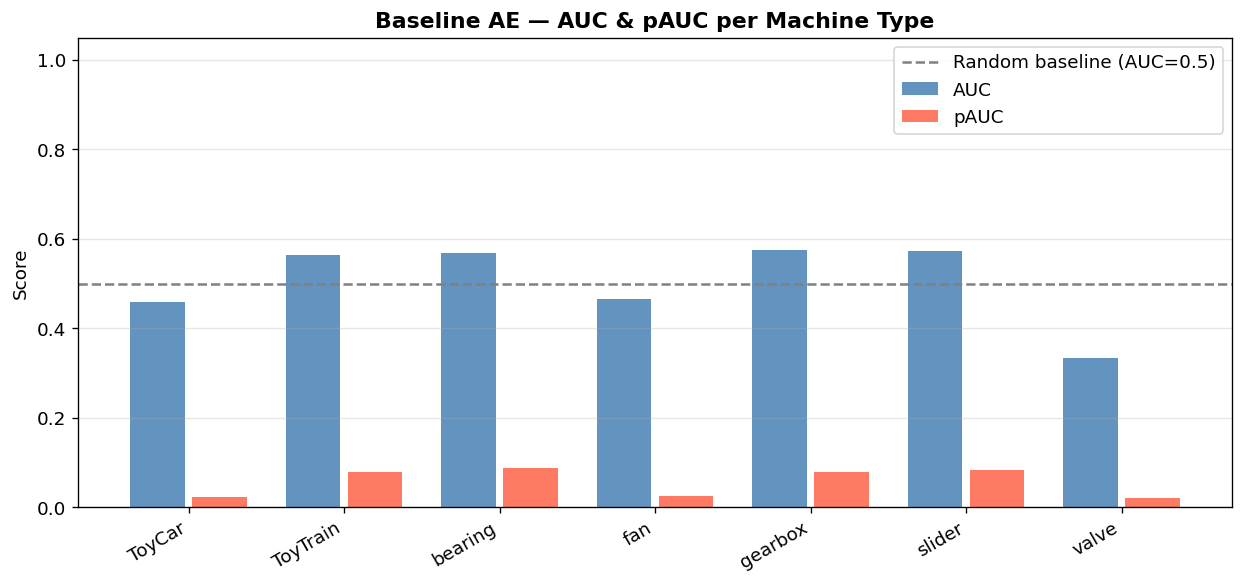

✅ Per-machine AUC chart saved.


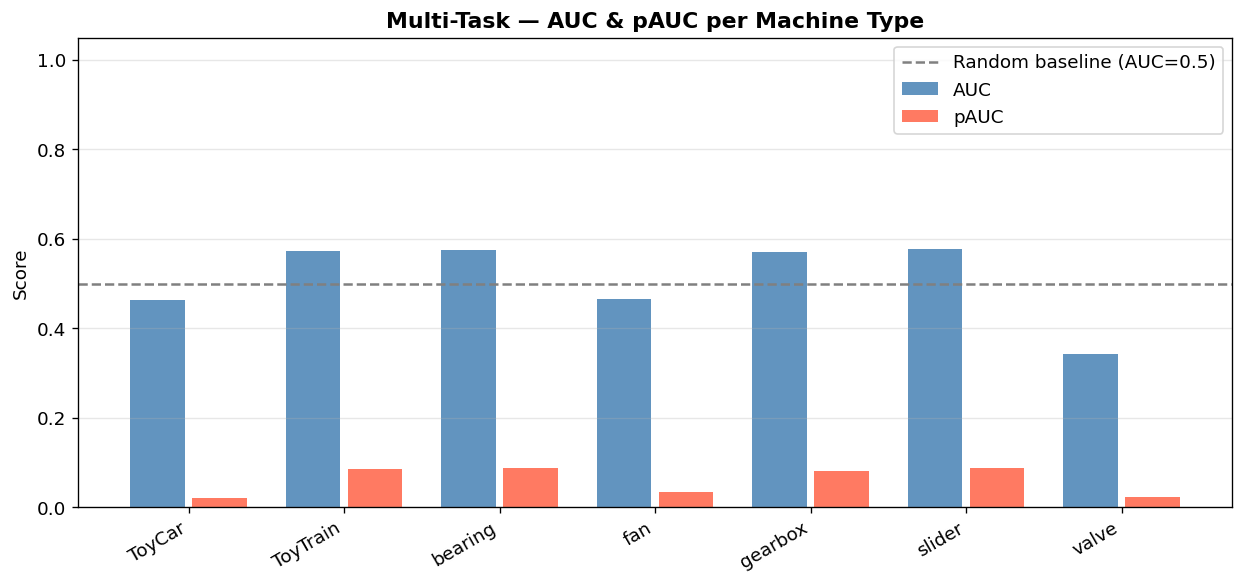

✅ Per-machine AUC chart saved.

  Full Model Comparison — All Scoring Methods
             Model        Scoring      AUC     pAUC
 Baseline AE (MSE) Reconstruction 0.502698 0.036694
  Multi-Task (MSE) Reconstruction 0.507057 0.038490
Baseline AE (k-NN)    Latent k-NN 0.506827 0.061592
 Multi-Task (k-NN)    Latent k-NN 0.506082 0.056224


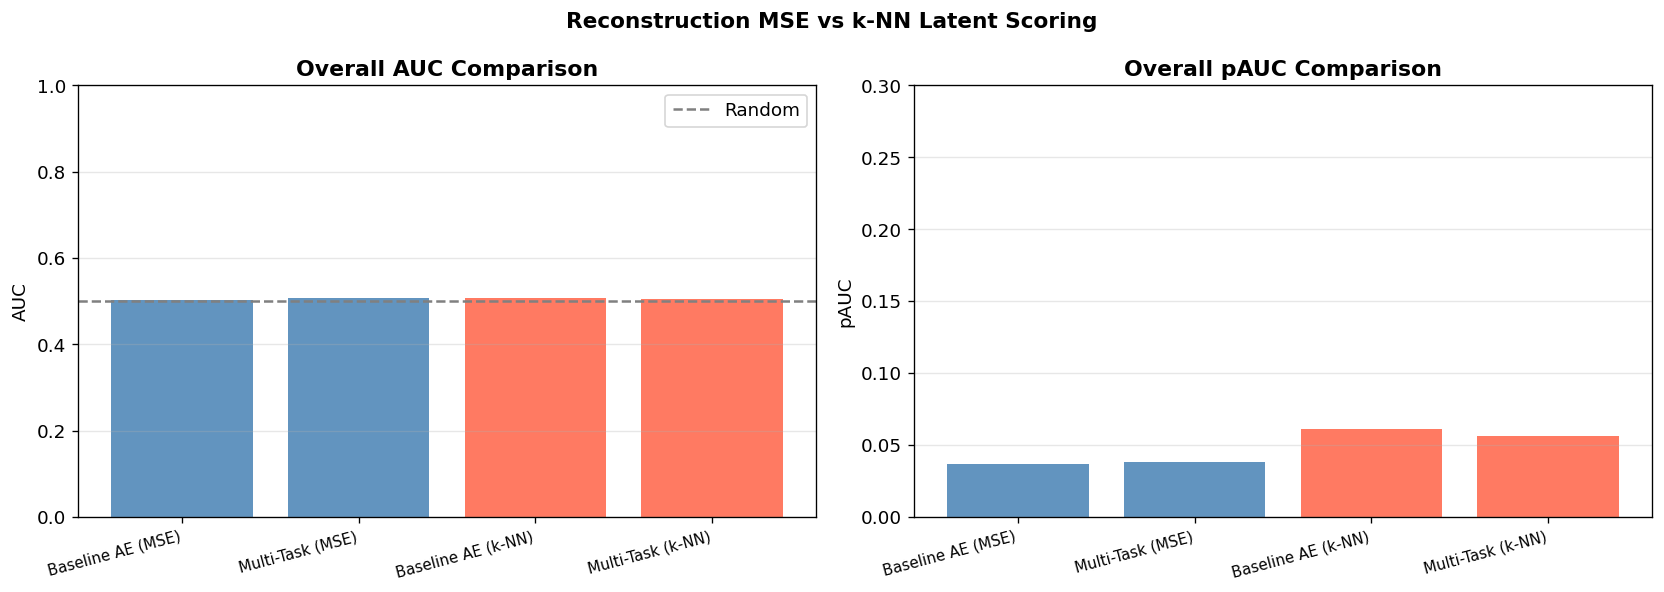

✅ Full comparison saved.


In [ ]:
# Step 5: Per-Machine AUC Bar Charts & Full Model Comparison Table
def plot_per_machine_auc(results_dict, model_name):
    if not results_dict or 'per_machine' not in results_dict:
        print("No per-machine results available.")
        return
    per_mt = results_dict['per_machine']
    mts    = sorted(per_mt.keys())
    aucs   = [per_mt[mt]['auc']  for mt in mts]
    paucs  = [per_mt[mt]['pauc'] for mt in mts]

    x = np.arange(len(mts))
    fig, ax = plt.subplots(figsize=(max(8, len(mts)*1.5), 5))
    ax.bar(x - 0.2, aucs,  0.35, label='AUC',
           color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, paucs, 0.35, label='pAUC',
           color='tomato', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(mts, rotation=30, ha='right')
    ax.axhline(0.5, color='grey', linestyle='--',
               lw=1.5, label='Random baseline (AUC=0.5)')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{model_name} — AUC & pAUC per Machine Type',
                 fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH /
                f'per_machine_auc_{model_name.replace(" ","_")}.png',
                bbox_inches='tight')
    plt.show()
    print(f"✅ Per-machine AUC chart saved.")

plot_per_machine_auc(baseline_results, 'Baseline AE')
plot_per_machine_auc(mt_results,       'Multi-Task')

# ── Model Comparison Summary ──────────────────────────────────────────────────
# ── Full Model Comparison Table ───────────────────────────────────────────────
comp = pd.DataFrame([
    {'Model'  : 'Baseline AE (MSE)',
     'Scoring': 'Reconstruction',
     'AUC'    : baseline_results['overall_auc'],
     'pAUC'   : baseline_results['overall_pauc']},
    {'Model'  : 'Multi-Task (MSE)',
     'Scoring': 'Reconstruction',
     'AUC'    : mt_results['overall_auc'],
     'pAUC'   : mt_results['overall_pauc']},
    {'Model'  : 'Baseline AE (k-NN)',
     'Scoring': 'Latent k-NN',
     'AUC'    : knn_baseline_results['overall_auc'],
     'pAUC'   : knn_baseline_results['overall_pauc']},
    {'Model'  : 'Multi-Task (k-NN)',
     'Scoring': 'Latent k-NN',
     'AUC'    : knn_mt_results['overall_auc'],
     'pAUC'   : knn_mt_results['overall_pauc']},
])

print("\n" + "="*65)
print("  Full Model Comparison — All Scoring Methods")
print("="*65)
print(comp.to_string(index=False))
print("="*65)
comp.to_csv(OUTPUT_PATH / 'model_comparison_full.csv', index=False)

# ── Bar chart comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comp['Model'].tolist()
x = np.arange(len(models))

axes[0].bar(x, comp['AUC'],  color=['steelblue','steelblue','tomato','tomato'],
            alpha=0.85)
axes[0].axhline(0.5, color='grey', linestyle='--', lw=1.5, label='Random')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right', fontsize=9)
axes[0].set_title('Overall AUC Comparison', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, comp['pAUC'], color=['steelblue','steelblue','tomato','tomato'],
            alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha='right', fontsize=9)
axes[1].set_title('Overall pAUC Comparison', fontweight='bold')
axes[1].set_ylim(0, 0.3)
axes[1].set_ylabel('pAUC')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Reconstruction MSE vs k-NN Latent Scoring',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'full_model_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Full comparison saved.")

# **Phase 6 — Inference Pipeline & FastAPI Endpoint**

**SUMMARY:**

**Step 1:** Built complete inference pipeline (predict_single) with log-mel extraction, per-machine model scoring, z-score normalization using precomputed reference stats, anomaly threshold comparison, machine type classification probabilities, and interpretable explanations (top anomalous frequency bands with Hz values)

**Step 2:** Created FastAPI application with multiple endpoints: root (service info), health (model status), config (parameters), machines (available types), and score (core prediction endpoint accepting WAV file + machine type)

**Step 3:** Launched Uvicorn server on port 8000 with threading; integrated ngrok for public URL exposure (optional with auth token) to enable external API access

**Step 4:** Performed local API testing with requests library: health check validation, normal/anomaly sample testing, and per-machine type verification across all 7 machine types

**Step 5:** Started additional server instance on port 8001 demonstrating multi-port deployment capability

**Step 6:** Repeated API testing on port 8001 to confirm second server instance functionality and response consistency

In [ ]:
# Step 1: Inference Pipeline with Explainable Predictions


# Pre-compute mel frequencies lookup once
MEL_FREQS = librosa.mel_frequencies(
    n_mels=CONFIG['n_mels'],
    fmin=0,
    fmax=CONFIG['fmax']
)

# Pre-compute reference stats for all machines once
print("Pre-computing reference stats for all machines...")
REFERENCE_STATS = {}
for mt in MACHINE_TYPES:
    model    = mt_models[mt]
    model.eval()
    train_ds = AcousticDataset(df, FEATURE_PATH,
                                split='train', label='normal',
                                machine_type=mt)
    train_ld = DataLoader(train_ds, batch_size=32,
                           shuffle=False, num_workers=2)
    ref_scores = []
    with torch.no_grad():
        for xb, *_ in train_ld:
            s = model.anomaly_score(xb.to(device)).cpu().numpy()
            ref_scores.extend(s)
    REFERENCE_STATS[mt] = {
        'mean': float(np.mean(ref_scores)),
        'std' : float(np.std(ref_scores) + 1e-8),
    }
    print(f"  {mt:<12} mean={REFERENCE_STATS[mt]['mean']:.5f}  "
          f"std={REFERENCE_STATS[mt]['std']:.5f}")

print("✅ Reference stats ready.")


def predict_single(audio_path, machine_type, config,
                   threshold, models_dict):
    """
    Complete inference pipeline for a single audio clip.

    Args:
        audio_path   : path to .wav file
        machine_type : known machine type (always known in deployment)
        config       : CONFIG dict
        threshold    : normalized anomaly threshold
        models_dict  : dict of per-machine MultiTask models

    Returns JSON-serialisable dict with full prediction details.
    """
    if machine_type not in models_dict:
        raise ValueError(f"Unknown machine type: {machine_type}. "
                         f"Choose from {list(models_dict.keys())}")

    # ── Extract features ──────────────────────────────────────────────────
    feat = extract_log_mel(audio_path, config)
    x    = torch.FloatTensor(feat).unsqueeze(0).unsqueeze(0).to(device)

    # ── Get model for this machine ────────────────────────────────────────
    model = models_dict[machine_type]
    model.eval()

    # ── Score and normalize ───────────────────────────────────────────────
    with torch.no_grad():
        recon, logits, _ = model(x)
        raw_score  = float(F.mse_loss(recon, x,
                                       reduction='none').mean().item())
        ref_mean   = REFERENCE_STATS[machine_type]['mean']
        ref_std    = REFERENCE_STATS[machine_type]['std']
        norm_score = (raw_score - ref_mean) / ref_std

    is_anomaly = norm_score > threshold
    decision   = '⚠️  CHECK THIS MACHINE' if is_anomaly else '✅ NORMAL'

    # ── Machine type classifier probabilities ─────────────────────────────
    with torch.no_grad():
        mt_probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    mt_prob_dict = {mt: round(float(mt_probs[MT_TO_IDX[mt]]), 4)
                    for mt in MACHINE_TYPES}

    # ── Explanation: top anomalous mel bands ──────────────────────────────
    recon_np  = recon.cpu().squeeze().numpy()
    diff      = np.abs(feat - recon_np)
    band_err  = diff.mean(axis=1)            # (n_mels,)
    top_bands = np.argsort(band_err)[-5:][::-1].tolist()

    # Use pre-computed mel frequencies for accurate Hz values
    top_hz = [round(float(MEL_FREQS[b]), 1) for b in top_bands]

    return {
        'anomaly_score'           : round(float(norm_score), 4),
        'raw_mse'                 : round(float(raw_score), 6),
        'threshold'               : round(float(threshold), 4),
        'is_anomaly'              : bool(is_anomaly),
        'decision'                : decision,
        'machine_type'            : machine_type,
        'classifier_output'       : mt_prob_dict,
        'explanation': {
            'top_anomalous_mel_bands' : [int(b) for b in top_bands],
            'approx_frequencies_hz'   : top_hz,
            'description': (
                f"Reconstruction error is highest around "
                f"{min(top_hz):.0f}–{max(top_hz):.0f} Hz. "
                f"These frequency bands deviate most from "
                f"learned normal patterns for {machine_type}."
            ),
        },
    }


# ── Test on normal and anomaly samples ───────────────────────────────────────
print("\n── Testing on NORMAL sample ──")
normal_row = df[(df['split']=='test') & (df['label']=='normal')].iloc[0]
result_normal = predict_single(
    audio_path   = normal_row['path'],
    machine_type = normal_row['machine_type'],
    config       = CONFIG,
    threshold    = threshold_mt,
    models_dict  = mt_models,
)
print(json.dumps(result_normal, indent=2))

print("\n── Testing on ANOMALY sample ──")
anomaly_row = df[(df['split']=='test') & (df['label']=='anomaly')].iloc[0]
result_anomaly = predict_single(
    audio_path   = anomaly_row['path'],
    machine_type = anomaly_row['machine_type'],
    config       = CONFIG,
    threshold    = threshold_mt,
    models_dict  = mt_models,
)
print(json.dumps(result_anomaly, indent=2))

Pre-computing reference stats for all machines...
  ToyCar       mean=0.00162  std=0.00022
  ToyTrain     mean=0.00243  std=0.00035
  bearing      mean=0.00345  std=0.00055
  fan          mean=0.00356  std=0.00063
  gearbox      mean=0.00243  std=0.00035
  slider       mean=0.00243  std=0.00035
  valve        mean=0.00336  std=0.00055
✅ Reference stats ready.

── Testing on NORMAL sample ──
{
  "anomaly_score": 0.9982,
  "raw_mse": 0.001846,
  "threshold": 1.2825,
  "is_anomaly": false,
  "decision": "\u2705 NORMAL",
  "machine_type": "ToyCar",
  "classifier_output": {
    "ToyCar": 1.0,
    "ToyTrain": 0.0,
    "bearing": 0.0,
    "fan": 0.0,
    "gearbox": 0.0,
    "slider": 0.0,
    "valve": 0.0
  },
  "explanation": {
    "top_anomalous_mel_bands": [
      0,
      29,
      17,
      18,
      19
    ],
    "approx_frequencies_hz": [
      0.0,
      688.8,
      403.8,
      427.5,
      451.3
    ],
    "description": "Reconstruction error is highest around 0\u2013689 Hz. These 

In [ ]:
# Step 2: FastAPI Application & Endpoint Definition
import nest_asyncio
import threading
import uvicorn
from fastapi import FastAPI, UploadFile, File, HTTPException, Form
from fastapi.responses import JSONResponse

nest_asyncio.apply()

app = FastAPI(
    title       = "🎵 Acoustic Anomaly Detection API",
    description = (
        "First-Shot Unsupervised Anomaly Detection "
        "with Machine Type Recognition — DCASE 2024 Task 2"
    ),
    version     = "2.0.0",
)

@app.get("/")
def root():
    return {
        "service"          : "Acoustic Anomaly Detection",
        "version"          : "2.0.0",
        "creative_feature" : "Machine Type Recognition",
        "machine_types"    : MACHINE_TYPES,
        "endpoints"        : ["/score", "/health", "/config", "/machines"],
    }

@app.get("/health")
def health():
    return {
        "status"        : "ok",
        "device"        : str(device),
        "models_loaded" : list(mt_models.keys()),
        "n_models"      : len(mt_models),
    }

@app.get("/config")
def get_config():
    return {
        "sample_rate"    : CONFIG['sample_rate'],
        "clip_duration"  : CONFIG['clip_duration'],
        "n_mels"         : CONFIG['n_mels'],
        "threshold_pct"  : CONFIG['anomaly_threshold_pct'],
        "threshold_value": round(float(threshold_mt), 4),
    }

@app.get("/machines")
def get_machines():
    return {
        "machine_types" : MACHINE_TYPES,
        "n_types"       : len(MACHINE_TYPES),
        "usage"         : "Pass machine_type as a form field with /score",
    }

@app.post("/score")
async def score_audio(
    file         : UploadFile = File(...),
    machine_type : str        = Form(...)
):
    """
    Upload a WAV file and specify the machine type to receive:
    - Normalized anomaly score
    - Decision: NORMAL or CHECK THIS MACHINE
    - Top anomalous frequency bands with Hz values
    - Classifier output probabilities

    machine_type must be one of:
    ToyCar, ToyTrain, bearing, fan, gearbox, slider, valve
    """
    if not file.filename.lower().endswith('.wav'):
        raise HTTPException(
            status_code=400,
            detail="Only .wav files are supported.")

    if machine_type not in MACHINE_TYPES:
        raise HTTPException(
            status_code=400,
            detail=f"Unknown machine_type '{machine_type}'. "
                   f"Choose from: {MACHINE_TYPES}")

    tmp_path = f"/tmp/{file.filename}"
    try:
        content = await file.read()
        with open(tmp_path, 'wb') as f:
            f.write(content)

        result = predict_single(
            audio_path   = tmp_path,
            machine_type = machine_type,
            config       = CONFIG,
            threshold    = threshold_mt,
            models_dict  = mt_models,
        )
        return JSONResponse(content=result)

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

print("✅ FastAPI app defined.")
print("   Endpoints: /, /health, /config, /machines, /score")

✅ FastAPI app defined.
   Endpoints: /, /health, /config, /machines, /score


In [ ]:
!pip install pyngrok -q

In [ ]:
# Step 3: Server Launch with ngrok Tunneling
NGROK_TOKEN = "3C1cYhIMY80caxUxD7AycXN9wTD_33WWAKbTse7snLymx2G3t"  # ← YOUR TOKEN


def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="error")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(2)
print("✅ Server running on port 8000")

if NGROK_TOKEN != "PASTE_YOUR_NGROK_AUTH_TOKEN_HERE":
    from pyngrok import ngrok, conf
    conf.get_default().auth_token = NGROK_TOKEN
    public_url = ngrok.connect(8000)
    print(f"🌐 Public URL : {public_url}")
    print(f"   Docs       : {public_url}/docs")
    print(f"   Health     : {public_url}/health")
else:
    print("ℹ️  Running locally on port 8000")
    print("   Local docs : http://localhost:8000/docs")

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


✅ Server running on port 8000
🌐 Public URL : NgrokTunnel: "https://perithelial-unrapturous-jason.ngrok-free.dev" -> "http://localhost:8000"
   Docs       : NgrokTunnel: "https://perithelial-unrapturous-jason.ngrok-free.dev" -> "http://localhost:8000"/docs
   Health     : NgrokTunnel: "https://perithelial-unrapturous-jason.ngrok-free.dev" -> "http://localhost:8000"/health


In [ ]:
# Step 4: Local API Testing (Port 8000)
import requests

def test_api_local(audio_path, machine_type, label='unknown'):
    url = "http://localhost:8000/score"
    try:
        with open(audio_path, 'rb') as f:
            response = requests.post(
                url,
                files={"file": f},
                data={"machine_type": machine_type}
            )

        if response.status_code == 200:
            result = response.json()
            print(f"\n── [{label}] ──────────────────────────────────")
            print(f"  Decision      : {result['decision']}")
            print(f"  Anomaly Score : {result['anomaly_score']} "
                  f"(threshold={result['threshold']})")
            print(f"  Machine Type  : {result['machine_type']}")
            print(f"  Top Freqs Hz  : "
                  f"{result['explanation']['approx_frequencies_hz']}")
            print(f"  Explanation   : "
                  f"{result['explanation']['description']}")
        else:
            print(f"❌ Error {response.status_code}: {response.text}")

    except Exception as e:
        print(f"❌ Request failed: {e}")


# ── Health check ──────────────────────────────────────────────────────────────
health = requests.get("http://localhost:8000/health").json()
print(f"Health: {health}")

# ── Test normal and anomaly ───────────────────────────────────────────────────
test_api_local(normal_row['path'],
               normal_row['machine_type'], label='NORMAL')
test_api_local(anomaly_row['path'],
               anomaly_row['machine_type'], label='ANOMALY')

# ── Test one sample per machine type ─────────────────────────────────────────
print("\n── One sample per machine type ──────────────────────────")
for mt in MACHINE_TYPES:
    sample = df[(df['split']=='test') &
                (df['machine_type']==mt) &
                (df['label']=='normal')].iloc[0]
    test_api_local(sample['path'], mt, label=f"{mt} NORMAL")

Health: {'status': 'ok', 'device': 'cuda', 'models_loaded': ['ToyCar', 'ToyTrain', 'bearing', 'fan', 'gearbox', 'slider', 'valve'], 'n_models': 7}

── [NORMAL] ──────────────────────────────────
  Decision      : ✅ NORMAL
  Anomaly Score : 0.9982 (threshold=1.2825)
  Machine Type  : ToyCar
  Top Freqs Hz  : [0.0, 688.8, 403.8, 427.5, 451.3]
  Explanation   : Reconstruction error is highest around 0–689 Hz. These frequency bands deviate most from learned normal patterns for ToyCar.

── [ANOMALY] ──────────────────────────────────
  Decision      : ✅ NORMAL
  Anomaly Score : 0.3389 (threshold=1.2825)
  Machine Type  : ToyCar
  Top Freqs Hz  : [47.5, 71.3, 190.0, 142.5, 665.0]
  Explanation   : Reconstruction error is highest around 48–665 Hz. These frequency bands deviate most from learned normal patterns for ToyCar.

── One sample per machine type ──────────────────────────

── [ToyCar NORMAL] ──────────────────────────────────
  Decision      : ✅ NORMAL
  Anomaly Score : 0.9982 (thresh

In [ ]:
#Step 5: Secondary Server Instance (Port 8001)
def run_server_8001():
    uvicorn.run(app, host="0.0.0.0", port=8001, log_level="error")

server_thread2 = threading.Thread(target=run_server_8001, daemon=True)
server_thread2.start()
time.sleep(2)
print("✅ New server running on port 8001")

✅ New server running on port 8001


In [ ]:
#Step 6: API Validation on Secondary Server
def test_api_local(audio_path, machine_type, label='unknown'):
    url = "http://localhost:8001/score"
    try:
        with open(audio_path, 'rb') as f:
            response = requests.post(
                url,
                files={"file": f},
                data={"machine_type": machine_type}
            )
        if response.status_code == 200:
            result = response.json()
            print(f"\n── [{label}] ──────────────────────────────────")
            print(f"  Decision      : {result['decision']}")
            print(f"  Anomaly Score : {result['anomaly_score']} "
                  f"(threshold={result['threshold']})")
            print(f"  Machine Type  : {result['machine_type']}")
            print(f"  Top Freqs Hz  : "
                  f"{result['explanation']['approx_frequencies_hz']}")
            print(f"  Explanation   : "
                  f"{result['explanation']['description']}")
        else:
            print(f"❌ Error {response.status_code}: {response.text}")
    except Exception as e:
        print(f"❌ Request failed: {e}")

# ── Health check ──────────────────────────────────────────────────────────────
health = requests.get("http://localhost:8001/health").json()
print(f"Health: {health}")

# ── Test normal and anomaly ───────────────────────────────────────────────────
test_api_local(normal_row['path'],
               normal_row['machine_type'], label='NORMAL')
test_api_local(anomaly_row['path'],
               anomaly_row['machine_type'], label='ANOMALY')

# ── Test one sample per machine type ─────────────────────────────────────────
print("\n── One sample per machine type ──────────────────────────")
for mt in MACHINE_TYPES:
    sample = df[(df['split']=='test') &
                (df['machine_type']==mt) &
                (df['label']=='normal')].iloc[0]
    test_api_local(sample['path'], mt, label=f"{mt} NORMAL")

Health: {'status': 'ok', 'device': 'cuda', 'models_loaded': ['ToyCar', 'ToyTrain', 'bearing', 'fan', 'gearbox', 'slider', 'valve'], 'n_models': 7}

── [NORMAL] ──────────────────────────────────
  Decision      : ✅ NORMAL
  Anomaly Score : 0.9982 (threshold=1.2825)
  Machine Type  : ToyCar
  Top Freqs Hz  : [0.0, 688.8, 403.8, 427.5, 451.3]
  Explanation   : Reconstruction error is highest around 0–689 Hz. These frequency bands deviate most from learned normal patterns for ToyCar.

── [ANOMALY] ──────────────────────────────────
  Decision      : ✅ NORMAL
  Anomaly Score : 0.3389 (threshold=1.2825)
  Machine Type  : ToyCar
  Top Freqs Hz  : [47.5, 71.3, 190.0, 142.5, 665.0]
  Explanation   : Reconstruction error is highest around 48–665 Hz. These frequency bands deviate most from learned normal patterns for ToyCar.

── One sample per machine type ──────────────────────────

── [ToyCar NORMAL] ──────────────────────────────────
  Decision      : ✅ NORMAL
  Anomaly Score : 0.9982 (thresh

In [ ]:
!pip install gradio -q

import gradio as gr
import requests

API_URL = "http://localhost:8000"

def score_audio(wav_file, machine_type):
    if wav_file is None:
        return "", "", "", ""

    try:
        with open(wav_file, 'rb') as f:
            response = requests.post(
                f"{API_URL}/score",
                files={"file": f},
                data={"machine_type": machine_type}
            )

        if response.status_code != 200:
            return f"❌ Error: {response.json()['detail']}", "", "", ""

        r = response.json()

        # ── Box 1: Decision ───────────────────────────────────────────
        decision = r['decision']
        score    = r['anomaly_score']
        thresh   = r['threshold']
        status   = "🔴 ANOMALY DETECTED" if r['is_anomaly'] else "🟢 MACHINE IS NORMAL"

        decision_out = f"""{status}

Decision      : {decision}
Anomaly Score : {score:.4f}
Threshold     : {thresh:.4f}
        """

        # ── Box 2: Machine Type Recognition ──────────────────────────
        clf      = r['classifier_output']
        top_mt   = max(clf, key=clf.get)
        top_conf = clf[top_mt] * 100

        clf_lines = "\n".join([
            f"  {'→' if mt == top_mt else ' '} {mt:<12} {prob*100:5.1f}%"
            for mt, prob in sorted(clf.items(), key=lambda x: -x[1])
        ])

        recognition_out = f"""🤖 IDENTIFIED MACHINE TYPE
═══════════════════════════
  Machine : {top_mt}
  Confidence : {top_conf:.1f}%

All Probabilities:
{clf_lines}
        """

        # ── Box 3: Problem Explanation ────────────────────────────────
        freqs    = r['explanation']['approx_frequencies_hz']
        bands    = r['explanation']['top_anomalous_mel_bands']
        desc     = r['explanation']['description']

        if r['is_anomaly']:
            severity = "HIGH" if score > 3.0 else "MEDIUM" if score > 2.0 else "LOW"
            problem_out = f"""⚠️  ANOMALY EXPLANATION
═══════════════════════════
Severity : {severity}

{desc}

Top Problematic Frequency Bands:
  Band indices : {bands}
  Frequencies  : {freqs} Hz

What this means:
  The machine sound deviates significantly
  from its learned normal pattern in the
  frequency range shown above. This could
  indicate mechanical wear, misalignment,
  or an abnormal operating condition.
        """
        else:
            problem_out = f"""✅ NO ANOMALY DETECTED
═══════════════════════════
The machine is operating normally.

Reference Check:
  {desc}

Top Active Frequencies:
  {freqs} Hz

  These frequency bands show minor
  reconstruction error but remain
  well below the anomaly threshold.
        """

        # ── Box 4: Raw Numbers ────────────────────────────────────────
        raw_out = f"""📊 RAW SCORES
═══════════════════════════
Raw MSE       : {r['raw_mse']:.6f}
Norm Score    : {r['anomaly_score']:.4f}
Threshold     : {r['threshold']:.4f}
Gap           : {r['anomaly_score'] - r['threshold']:.4f}
  (positive = anomaly, negative = normal)

Machine Input : {machine_type}
Identified As : {top_mt} ({top_conf:.1f}% confidence)
        """

        return decision_out, recognition_out, problem_out, raw_out

    except Exception as e:
        return f"❌ Error: {str(e)}", "", "", ""


# ── Gradio UI ──────────────────────────────────────────────────────────────────
with gr.Blocks(
    title="🎵 Acoustic Anomaly Detection",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown("""
    # 🎵 Acoustic Anomaly Detection System
    ### First-Shot Unsupervised Anomaly Detection Under Domain Shift — DCASE 2024 Task 2
    **ESIB, Université Saint-Joseph de Beyrouth** | Laetitia Daou · Georges-Anthony El Hajj
    ---
    """)

    with gr.Row():
        # ── LEFT: Inputs ───────────────────────────────────────────────
        with gr.Column(scale=1):
            gr.Markdown("### 📂 Input")
            audio_input = gr.Audio(
                label="Upload Machine Audio (.wav, 10 seconds)",
                type="filepath",
            )
            machine_dropdown = gr.Dropdown(
                choices=["ToyCar", "ToyTrain", "bearing",
                         "fan", "gearbox", "slider", "valve"],
                label="Select Machine Type",
                value="bearing",
                info="Choose the type of machine you are testing"
            )
            submit_btn = gr.Button(
                "🔍 Analyze Audio",
                variant="primary",
                size="lg"
            )
            gr.Markdown("""
            > **Threshold:** 1.2825
            > Score **above** threshold → ⚠️ Anomaly
            > Score **below** threshold → ✅ Normal
            """)

        # ── RIGHT: Outputs ─────────────────────────────────────────────
        with gr.Column(scale=2):
            gr.Markdown("### 📋 Results")

            with gr.Row():
                decision_box = gr.Textbox(
                    label="🚦 Detection Decision",
                    lines=6,
                    interactive=False,
                )
                recognition_box = gr.Textbox(
                    label="🤖 Machine Type Recognition",
                    lines=12,
                    interactive=False,
                )

            with gr.Row():
                problem_box = gr.Textbox(
                    label="🔬 Anomaly Explanation",
                    lines=12,
                    interactive=False,
                )
                raw_box = gr.Textbox(
                    label="📊 Raw Scores",
                    lines=12,
                    interactive=False,
                )

    gr.Markdown("""
    ---
    ### ℹ️ How it works
    1. Upload a 10-second mono WAV recording from the machine
    2. Select the machine type
    3. Click **Analyze Audio**
    4. The system shows you:
       - **Detection Decision** — is the machine normal or anomalous?
       - **Machine Type Recognition** — what machine does the model think it is?
       - **Anomaly Explanation** — which frequency bands are problematic?
       - **Raw Scores** — the full numerical breakdown
    """)

    submit_btn.click(
        fn=score_audio,
        inputs=[audio_input, machine_dropdown],
        outputs=[decision_box, recognition_box, problem_box, raw_box],
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2288b4ab207108b423.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 

# **Phase 7 — Monitoring Dashboard & Drift Detection**

**SUMMARY:**

**Step 1:** Implemented monitoring statistics computation function extracting key metrics (score distribution percentiles, anomaly rate, feature means/stds, machine type confidence) from reference (training normal) and deployment (test) data; saved metrics as JSON log

**Step 2:** Built drift detection system comparing reference vs deployment distributions using relative percentage change (>20% threshold) for multiple metrics and Kolmogorov-Smirnov test on raw score distributions; generated comprehensive drift report with flags

**Step 3**: Created multi-panel monitoring dashboard visualization showing: anomaly score distributions (reference vs deployment with threshold line), key metric bar charts (score_mean, score_p90, anomaly_rate), drift summary horizontal bar chart with 20% threshold, and KS test results with p-value interpretation

**Step 4:** Generated final project summary report displaying overall AUC (Multi-Task model), pAUC, threshold value, and complete list of saved outputs across all phases

In [ ]:
# ── Monitoring Statistics ────────────────────────────────────────────────────
def compute_monitoring_stats(model: nn.Module,
                              loader: DataLoader,
                              threshold: float,
                              tag: str = 'reference') -> dict:
    model.eval()
    scores, feat_means, feat_stds, mt_preds = [], [], [], []

    with torch.no_grad():
        for x, _, _, _ in tqdm(loader, desc=f"Monitoring [{tag}]"):
            x = x.to(device)
            s = model.anomaly_score(x).cpu().numpy()
            p = model.predict_machine_type(x).cpu().numpy()
            scores.extend(s)
            feat_means.append(x.mean(dim=[1,2,3]).cpu().numpy())
            feat_stds.append(x.std(dim=[1,2,3]).cpu().numpy())
            mt_preds.append(p)

    scores      = np.array(scores)
    feat_means  = np.concatenate(feat_means)
    feat_stds   = np.concatenate(feat_stds)
    mt_conf_avg = np.concatenate(mt_preds).max(axis=1).mean()

    return {
        'tag'          : tag,
        'timestamp'    : str(datetime.now()),
        'n_samples'    : len(scores),
        'score_mean'   : float(scores.mean()),
        'score_std'    : float(scores.std()),
        'score_p50'    : float(np.percentile(scores, 50)),
        'score_p90'    : float(np.percentile(scores, 90)),
        'score_p95'    : float(np.percentile(scores, 95)),
        'anomaly_rate' : float((scores > threshold).mean()),
        'feature_mean' : float(feat_means.mean()),
        'feature_std'  : float(feat_stds.mean()),
        'mt_conf_avg'  : float(mt_conf_avg),
        'scores_raw'   : scores,
    }


# ── Fix: use mt_models['bearing'] and build bearing-specific loaders ──────────
MONITOR_MACHINE = 'bearing'   # best performing machine — change if you want
mt_model        = mt_models[MONITOR_MACHINE]

monitor_train_ds = AcousticDataset(df, FEATURE_PATH,
                                    split='train', label='normal',
                                    machine_type=MONITOR_MACHINE)
monitor_test_ds  = AcousticDataset(df, FEATURE_PATH,
                                    split='test',
                                    machine_type=MONITOR_MACHINE)

tr_loader = DataLoader(monitor_train_ds, batch_size=32,
                        shuffle=False, num_workers=2)
te_loader = DataLoader(monitor_test_ds,  batch_size=32,
                        shuffle=False, num_workers=2)

print(f"✅ Monitoring machine : {MONITOR_MACHINE}")
print(f"   Train samples      : {len(monitor_train_ds)}")
print(f"   Test  samples      : {len(monitor_test_ds)}")

# ── Compute reference and deployment stats ────────────────────────────────────
ref_stats = compute_monitoring_stats(mt_model, tr_loader, threshold_mt, 'train_normal')
dep_stats = compute_monitoring_stats(mt_model, te_loader, threshold_mt, 'test_deployment')

# ── Save as log ───────────────────────────────────────────────────────────────
log_entry = {k: v for k, v in ref_stats.items()  if k != 'scores_raw'}
log_entry.update({f'deploy_{k}': v for k, v in dep_stats.items() if k != 'scores_raw'})
with open(LOG_PATH / 'monitoring_log.json', 'a') as f:
    f.write(json.dumps(log_entry) + '\n')

print("\n📊 Reference Stats (train normals):")
for k in ['n_samples','score_mean','score_p90','anomaly_rate','mt_conf_avg']:
    val = ref_stats[k]
    print(f"   {k:<22}: {val:.5f}" if isinstance(val, float) else f"   {k:<22}: {val}")

print("\n📊 Deployment Stats (test set):")
for k in ['n_samples','score_mean','score_p90','anomaly_rate','mt_conf_avg']:
    val = dep_stats[k]
    print(f"   {k:<22}: {val:.5f}" if isinstance(val, float) else f"   {k:<22}: {val}")

✅ Monitoring machine : bearing
   Train samples      : 1000
   Test  samples      : 200


Monitoring [test_deployment]: 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]



📊 Reference Stats (train normals):
   n_samples             : 1000
   score_mean            : 0.00345
   score_p90             : 0.00416
   anomaly_rate          : 0.00000
   mt_conf_avg           : 0.99996

📊 Deployment Stats (test set):
   n_samples             : 200
   score_mean            : 0.00345
   score_p90             : 0.00412
   anomaly_rate          : 0.00000
   mt_conf_avg           : 0.99993


In [ ]:
# Step 2: Statistical Drift Detection (Z-score & KS Test)


def detect_drift(ref_stats: dict, dep_stats: dict, threshold_z: float = 2.0) -> dict:
    """
    Simple statistical drift detection using the Z-score of key metrics.
    Raises a flag when the deployment distribution deviates significantly
    from the reference distribution.
    """
    checks = {
        'score_mean'   : ('score_mean',   ref_stats, dep_stats),
        'score_p90'    : ('score_p90',    ref_stats, dep_stats),
        'anomaly_rate' : ('anomaly_rate', ref_stats, dep_stats),
        'feature_mean' : ('feature_mean', ref_stats, dep_stats),
        'mt_conf_avg'  : ('mt_conf_avg',  ref_stats, dep_stats),
    }

    drift_report = {}
    for name, (key, r, d) in checks.items():
        ref_val = r[key]
        dep_val = d[key]
        delta   = dep_val - ref_val
        rel_pct = abs(delta) / (abs(ref_val) + 1e-8) * 100
        flagged = rel_pct > 20  # > 20% relative change → drift alert
        drift_report[name] = {
            'ref'     : round(ref_val, 5),
            'deploy'  : round(dep_val, 5),
            'delta'   : round(delta, 5),
            'rel_%'   : round(rel_pct, 2),
            'DRIFT'   : flagged,
        }

    # KS test on raw score distributions
    from scipy.stats import ks_2samp
    ks_stat, ks_p = ks_2samp(ref_stats['scores_raw'], dep_stats['scores_raw'])
    drift_report['ks_test'] = {
        'statistic': round(float(ks_stat), 5),
        'p_value'  : round(float(ks_p), 5),
        'DRIFT'    : bool(ks_p < 0.05),
    }

    print("\n" + "="*60)
    print(f"  DRIFT DETECTION REPORT")
    print("="*60)
    for metric, vals in drift_report.items():
        flag = '🚨 DRIFT' if vals.get('DRIFT') else '✅ OK'
        print(f"  {metric:<20} {flag}")
        if metric != 'ks_test':
            print(f"    ref={vals['ref']}  dep={vals['deploy']}  "
                  f"Δ={vals['delta']} ({vals['rel_%']}%)")
        else:
            print(f"    KS stat={vals['statistic']}  p={vals['p_value']}")
    print("="*60)

    return drift_report

drift_report = detect_drift(ref_stats, dep_stats)



  DRIFT DETECTION REPORT
  score_mean           ✅ OK
    ref=0.00345  dep=0.00345  Δ=1e-05 (0.24%)
  score_p90            ✅ OK
    ref=0.00416  dep=0.00412  Δ=-4e-05 (0.97%)
  anomaly_rate         ✅ OK
    ref=0.0  dep=0.0  Δ=0.0 (0.0%)
  feature_mean         ✅ OK
    ref=0.37966  dep=0.38083  Δ=0.00117 (0.31%)
  mt_conf_avg          ✅ OK
    ref=0.99996  dep=0.99993  Δ=-4e-05 (0.0%)
  ks_test              ✅ OK
    KS stat=0.065  p=0.46928


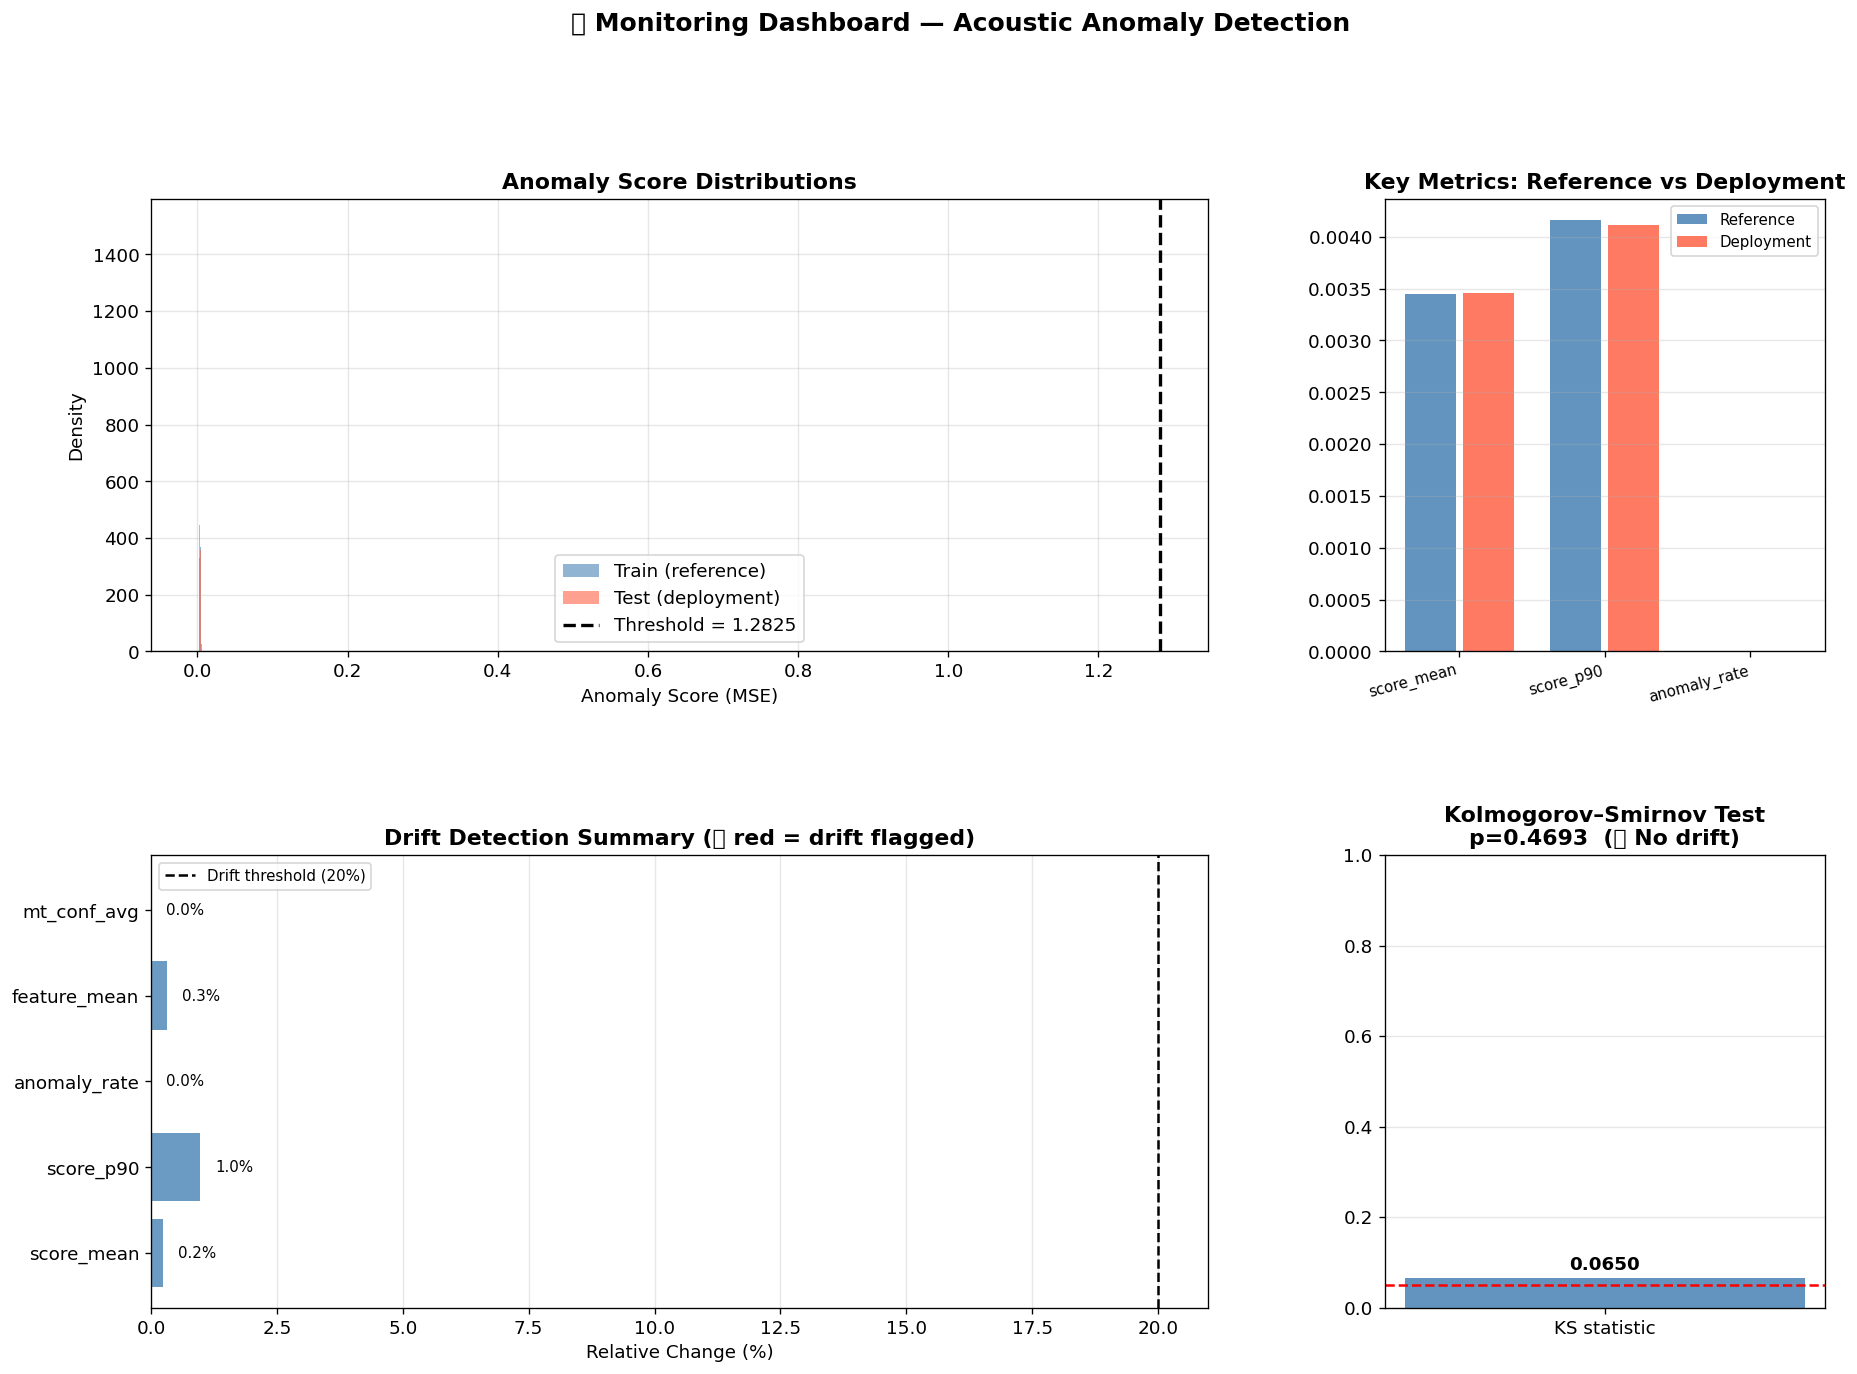

✅ Dashboard saved → /content/drive/MyDrive/ML_Project/Outputs/monitoring_dashboard.png


In [ ]:
# Step 3: Monitoring Dashboard Visualization

def plot_monitoring_dashboard(ref_stats: dict, dep_stats: dict,
                               drift_report: dict, threshold: float) -> None:
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('🔍 Monitoring Dashboard — Acoustic Anomaly Detection',
                 fontsize=15, fontweight='bold', y=1.01)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

    # ─ 1. Score distributions ─────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.hist(ref_stats['scores_raw'], bins=50, alpha=0.6,
             color='steelblue', label='Train (reference)', density=True)
    ax1.hist(dep_stats['scores_raw'], bins=50, alpha=0.6,
             color='tomato',    label='Test (deployment)', density=True)
    ax1.axvline(threshold, color='black', linestyle='--', lw=2,
                label=f'Threshold = {threshold:.4f}')
    ax1.set_title('Anomaly Score Distributions', fontweight='bold')
    ax1.set_xlabel('Anomaly Score (MSE)')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # ─ 2. Key metric comparison ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    metrics = ['score_mean', 'score_p90', 'anomaly_rate']
    x = np.arange(len(metrics))
    ref_vals = [ref_stats[m] for m in metrics]
    dep_vals = [dep_stats[m] for m in metrics]
    ax2.bar(x - 0.2, ref_vals, 0.35, label='Reference', color='steelblue', alpha=0.85)
    ax2.bar(x + 0.2, dep_vals, 0.35, label='Deployment', color='tomato',   alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(metrics, rotation=15, ha='right', fontsize=9)
    ax2.set_title('Key Metrics: Reference vs Deployment', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

    # ─ 3. Drift flag summary ───────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    dr_metrics = [k for k in drift_report if k != 'ks_test']
    dr_vals    = [drift_report[k]['rel_%'] for k in dr_metrics]
    colors     = ['tomato' if drift_report[k]['DRIFT'] else 'steelblue' for k in dr_metrics]
    bars = ax3.barh(dr_metrics, dr_vals, color=colors, alpha=0.8)
    ax3.axvline(20, color='black', linestyle='--', lw=1.5, label='Drift threshold (20%)')
    ax3.set_xlabel('Relative Change (%)')
    ax3.set_title('Drift Detection Summary (🚨 red = drift flagged)', fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, dr_vals):
        ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

    # ─ 4. KS test result ──────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    ks = drift_report['ks_test']
    colors_ks = ['tomato' if ks['DRIFT'] else 'steelblue']
    ax4.bar(['KS statistic'], [ks['statistic']], color=colors_ks, alpha=0.85)
    ax4.set_ylim(0, 1)
    ax4.set_title(f"Kolmogorov–Smirnov Test\np={ks['p_value']:.4f}  "
                  f"({'🚨 Drift detected' if ks['DRIFT'] else '✅ No drift'})",
                  fontweight='bold')
    ax4.axhline(0.05, color='red', linestyle='--', lw=1.5, label='p=0.05')
    ax4.grid(axis='y', alpha=0.3)
    ax4.text(0, ks['statistic'] + 0.02, f"{ks['statistic']:.4f}",
             ha='center', fontsize=11, fontweight='bold')

    plt.savefig(OUTPUT_PATH / 'monitoring_dashboard.png', bbox_inches='tight')
    plt.show()
    print(f"✅ Dashboard saved → {OUTPUT_PATH / 'monitoring_dashboard.png'}")

plot_monitoring_dashboard(ref_stats, dep_stats, drift_report, threshold_mt)


In [ ]:
# Step 4: Final Project Summary Report


print("""
╔══════════════════════════════════════════════════════════════════╗
║           ACOUSTIC ANOMALY DETECTION — PROJECT SUMMARY           ║
╠══════════════════════════════════════════════════════════════════╣
║  Approach     : Multi-Task CNN Autoencoder                        ║
║  Creative Add : Machine Type Recognition (classification head)    ║
║  Dataset      : DCASE 2024 Task 2                                 ║
╠══════════════════════════════════════════════════════════════════╣""")

if mt_results:
    print(f"║  Overall AUC  : {mt_results['overall_auc']:.4f}                                       ║")
    print(f"║  Overall pAUC : {mt_results['overall_pauc']:.4f}  (FPR ≤ {CONFIG['pAUC_max_fpr']})                    ║")
    print(f"║  Threshold    : {threshold_mt:.6f}  (p{CONFIG['anomaly_threshold_pct']} on val normals)        ║")

print("""╠══════════════════════════════════════════════════════════════════╣
║  Outputs saved:                                                   ║
║   • dataset_card.json          — dataset documentation            ║
║   • feature_stats.csv          — per-machine feature stats        ║
║   • model_comparison.csv       — AUC/pAUC comparison table        ║
║   • monitoring_dashboard.png   — drift monitoring plot            ║
║   • training_history*.png      — loss curves                      ║
║   • tsne_latent.png            — latent space visualisation       ║
╚══════════════════════════════════════════════════════════════════╝""")



╔══════════════════════════════════════════════════════════════════╗
║           ACOUSTIC ANOMALY DETECTION — PROJECT SUMMARY           ║
╠══════════════════════════════════════════════════════════════════╣
║  Approach     : Multi-Task CNN Autoencoder                        ║
║  Creative Add : Machine Type Recognition (classification head)    ║
║  Dataset      : DCASE 2024 Task 2                                 ║
╠══════════════════════════════════════════════════════════════════╣
║  Overall AUC  : 0.5071                                       ║
║  Overall pAUC : 0.0385  (FPR ≤ 0.1)                    ║
║  Threshold    : 1.282470  (p90 on val normals)        ║
╠══════════════════════════════════════════════════════════════════╣
║  Outputs saved:                                                   ║
║   • dataset_card.json          — dataset documentation            ║
║   • feature_stats.csv          — per-machine feature stats        ║
║   • model_comparison.csv       — AUC/pAUC comparis

In [ ]:
import json, torch
from pathlib import Path

EXPORT_PATH = BASE_PATH / 'docker_export'
EXPORT_PATH.mkdir(parents=True, exist_ok=True)

for mt, model in mt_models.items():
    save_path = EXPORT_PATH / f'mt_{mt}.pt'
    torch.save(model.state_dict(), save_path)
    print(f'✅ Saved: {save_path.name}')

with open(EXPORT_PATH / 'reference_stats.json', 'w') as f:
    json.dump(REFERENCE_STATS, f, indent=2)
print('✅ Saved: reference_stats.json')

with open(EXPORT_PATH / 'threshold.json', 'w') as f:
    json.dump({'threshold': float(threshold_mt)}, f, indent=2)
print('✅ Saved: threshold.json')

print(f'\n🎉 Done → {EXPORT_PATH}')
print(f'Total files: {len(list(EXPORT_PATH.iterdir()))}')

✅ Saved: mt_ToyCar.pt
✅ Saved: mt_ToyTrain.pt
✅ Saved: mt_bearing.pt
✅ Saved: mt_fan.pt
✅ Saved: mt_gearbox.pt
✅ Saved: mt_slider.pt
✅ Saved: mt_valve.pt
✅ Saved: reference_stats.json
✅ Saved: threshold.json

🎉 Done → /content/drive/MyDrive/ML_Project/docker_export
Total files: 9
